# U-Net VQ-VAE Diffusion Model Validation


## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from implied_volatility_diffusion import (
    DiffusionModel,
    MAGViTv2VQVAE,
    ReverseDiffusion,
    SurfaceNormalizer,
    UnifiedGrid,
    UNet,
    VPNoiseScheduler,
    check_iv_surface_arbitrage,
    repair_iv_surface,
    volgan_generative_repair_settings,
)
from implied_volatility_diffusion.diffusion.autoencoders.vqvae_trainer import load_vqvae_checkpoint


def _select_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
REPO_ROOT = Path.cwd().resolve()
for _candidate in (REPO_ROOT, *REPO_ROOT.parents):
    if (_candidate / "config").is_dir() and (_candidate / "src").is_dir():
        REPO_ROOT = _candidate
        break
else:
    raise RuntimeError("could not find repository root (expected config/ and src/)")
CFG_DIR = REPO_ROOT / "config"
import sys

if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))
import importlib
import plot_style
importlib.reload(plot_style)
from plot_style import (
    DIFF_CMAP,
    SURF_CMAP,
    TENOR_COLORS,
    HM_CBAR_TICK_LABELSIZE,
    HM_LABEL_FONTSIZE,
    HM_TICK_LABELSIZE,
    HM_TITLE_FONTSIZE,
    XSEC_LABEL_FONTSIZE,
    XSEC_LEGEND_FONTSIZE,
    XSEC_TICK_LABELSIZE,
    XSEC_TITLE_FONTSIZE,
    apply_theme,
    rc_context,
    style_2d_axes,
    style_3d_axes,
)

PLOT_THEME = "plotnine"
apply_theme(PLOT_THEME)

DATASET_ROOT = REPO_ROOT / "data" / "processed" / "forecasting_dataset"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / "diffusion_unet_vq.pt"
VQVAE_CHECKPOINT_PATH = CHECKPOINT_DIR / "vqvae.pt"
CONFIG_PATH = CHECKPOINT_DIR / "training_config.json"

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(f"missing {DATASET_ROOT / 'manifest.json'}; run notebooks/data/data_pipeline.ipynb first")
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"missing {CHECKPOINT_PATH}; run notebooks/training/u_net_training.ipynb with USE_MAGVIT_VQVAE=True first"
    )

print(f"compute device: {DEVICE}")
print(f"unified grid: {GRID.shape}")


compute device: mps
unified grid: (41, 40)


##  Validation Inputs

In [2]:
PATH_TYPES = ("historical", "sabr", "heston")
TENOR_SLICES_PER_SURFACE = 3
DDIM_STEPS = 200
ARB_DIAG_TOL = 1e-6
IV_FLOOR_SAMPLE = 1e-4
ARB_ACCEPT_TOL = 1e-4
GENERATED_ARB_TOL = ARB_ACCEPT_TOL
APPLY_SURFACE_REPAIR = True
FORECAST_REPAIR_SETTINGS = volgan_generative_repair_settings(
    tol=GENERATED_ARB_TOL,
    iv_floor=IV_FLOOR_SAMPLE,
)
SAMPLER_CLIP_Z = (-4.0, 4.0)

SOURCE_LABELS = {0: "historical", 1: "heston", 2: "sabr"}
PATH_TYPE_TO_SRC_ID = {"historical": 0, "heston": 1, "sabr": 2}
unknown_paths = [p for p in PATH_TYPES if p not in PATH_TYPE_TO_SRC_ID]
if unknown_paths:
    raise ValueError(f"Unknown path types in PATH_TYPES: {unknown_paths}")

run_config = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
VALIDATION_SEED = int(run_config.get("seed", 42))
GENERATION_SEEDS = [VALIDATION_SEED + 9000 + i for i in range(len(PATH_TYPES))]

tenor_idx = np.linspace(0, GRID.shape[1] - 1, TENOR_SLICES_PER_SURFACE).round().astype(int)
tenor_idx = np.unique(tenor_idx)
if tenor_idx.size != TENOR_SLICES_PER_SURFACE:
    raise RuntimeError(f"Expected exactly {TENOR_SLICES_PER_SURFACE} unique tenor slices, got {tenor_idx.size}.")

validation_inputs_df = pd.DataFrame(
    [
        {"input": "checkpoint", "value": str(CHECKPOINT_PATH.relative_to(REPO_ROOT))},
        {"input": "training config", "value": str(CONFIG_PATH.relative_to(REPO_ROOT))},
        {"input": "dataset", "value": str(DATASET_ROOT.relative_to(REPO_ROOT))},
        {"input": "validation instances", "value": list(PATH_TYPES)},
        {"input": "tenors shown per surface", "value": TENOR_SLICES_PER_SURFACE},
        {"input": "selected tenor years", "value": np.round(GRID.tau[tenor_idx], 4).tolist()},
        {"input": "DDIM steps", "value": DDIM_STEPS},
        {"input": "base generation seeds", "value": GENERATION_SEEDS},
        {"input": "strict diagnostic tol", "value": ARB_DIAG_TOL},
        {"input": "soft acceptance tol", "value": ARB_ACCEPT_TOL},
        {"input": "required forecast arbitrage tol", "value": GENERATED_ARB_TOL},
        {"input": "VolGAN surface repair", "value": APPLY_SURFACE_REPAIR},
    ]
)
display(validation_inputs_df)

,input,value
0,checkpoint,data/processed/checkpoints/diffusion_unet_vq.pt
1,training config,data/processed/checkpoints/training_config.json
2,dataset,data/processed/forecasting_dataset
3,validation instances,"[historical, sabr, heston]"
4,tenors shown per surface,3
5,selected tenor years,"[0.05, 1.05, 2.0]"
6,DDIM steps,200
7,base generation seeds,"[9042, 9043, 9044]"
8,strict diagnostic tol,0.000001
9,soft acceptance tol,0.0001


## Load validation pairs and checkpoint

In [3]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
normalizer = SurfaceNormalizer.load(DATASET_ROOT / "normalizer.npz")
assert tuple(normalizer.grid_shape) == tuple(GRID.shape), (
    f"normalizer grid {normalizer.grid_shape} != unified grid {GRID.shape}"
)

VAL_DIR = DATASET_ROOT / "validation"
val_pair_curr = np.load(VAL_DIR / "pair_curr.npy").astype(np.float32)
val_pair_next = np.load(VAL_DIR / "pair_next.npy").astype(np.float32)
val_sources = np.load(VAL_DIR / "pair_sources.npy")

pair_curr_by_src = {}
pair_next_by_src = {}
for _src_id in [0, 1, 2]:
    _mask = val_sources == _src_id
    pair_curr_by_src[_src_id] = val_pair_curr[_mask]
    pair_next_by_src[_src_id] = val_pair_next[_mask]

val_hist_curr_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_curr_dates.npy"))
val_hist_next_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_next_dates.npy"))
val_heston_paths = np.load(VAL_DIR / "heston_path.npy")
val_heston_steps = np.load(VAL_DIR / "heston_step.npy")
val_sabr_paths = np.load(VAL_DIR / "sabr_path.npy")
val_sabr_steps = np.load(VAL_DIR / "sabr_step.npy")

n_pairs_by_src = {k: int(v.shape[0]) for k, v in pair_curr_by_src.items()}
print(
    f"validation pairs by source -- historical={n_pairs_by_src[0]}  "
    f"heston={n_pairs_by_src[1]}  sabr={n_pairs_by_src[2]}"
    f"  (total={sum(n_pairs_by_src.values())})"
)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
SCHEDULER_TIMESTEPS = int(checkpoint.get("scheduler_timesteps", run_config.get("scheduler_timesteps", 400)))
_unet_kw = checkpoint.get("unet_kwargs") or run_config.get("unet_kwargs")
SPOT_REF = float(checkpoint.get("spot_ref", run_config.get("spot_ref", 100.0)))
RATE_REF = float(checkpoint.get("rate_ref", run_config.get("rate_ref", 0.03)))

if _unet_kw:
    backbone_kw = dict(_unet_kw)
    backbone = UNet(**backbone_kw)
    backbone_artifact = "U-Net kwargs"
    prediction_type = None
else:
    raise RuntimeError("Checkpoint missing `unet_kwargs` in checkpoint/run config.")

cond_channels = int(backbone_kw.get("cond_channels", 0))
if cond_channels < 1:
    raise RuntimeError(
        "Loaded checkpoint is unconditional (cond_channels=0). Re-run "
        "notebooks/training/u_net_training.ipynb with USE_MAGVIT_VQVAE=True to produce a conditional checkpoint."
    )

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")

_state = checkpoint.get("model_state_dict") or {}
_has_vq_weights = any(str(k).startswith("vqvae.") for k in _state)
_vqvae_kw = checkpoint.get("vqvae_kwargs") or run_config.get("vqvae_kwargs")
_use_vqvae = bool(
    checkpoint.get(
        "use_magvit_vqvae",
        run_config.get("use_magvit_vqvae", _vqvae_kw is not None or _has_vq_weights),
    )
)

if _use_vqvae and _vqvae_kw:
    _vq = MAGViTv2VQVAE(**{k: tuple(v) if isinstance(v, list) else v for k, v in _vqvae_kw.items()})
elif _use_vqvae:
    if not VQVAE_CHECKPOINT_PATH.exists():
        raise RuntimeError(
            "VQ-VAE U-Net checkpoint has no vqvae_kwargs and "
            f"{VQVAE_CHECKPOINT_PATH.name} is missing. Re-save the diffusion "
            "checkpoint with vqvae_kwargs, or keep the Stage-1 VQ-VAE weights."
        )
    _vq = load_vqvae_checkpoint(VQVAE_CHECKPOINT_PATH, map_location="cpu")
    _vqvae_kw = {
        "in_channels": 1,
        "latent_channels": int(_vq.latent_channels),
        "block_out_channels": list(_vq.vq_model.config.block_out_channels),
        "num_downsample": int(_vq.num_downsample),
        "num_vq_embeddings": int(_vq.codebook_size),
    }
    print(f"VQ-VAE architecture loaded from {VQVAE_CHECKPOINT_PATH.name}")
else:
    _vq = None

if _vq is not None:
    print(
        f"VQ-VAE enabled: latent_channels={_vq.latent_channels}, "
        f"codebook_size={_vq.codebook_size}, num_downsample={_vq.num_downsample}"
    )

model = DiffusionModel.from_surface_normalizer(
    backbone,
    scheduler,
    normalizer,
    prediction_type=prediction_type,
    vqvae=_vq,
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
if _use_vqvae:
    model.freeze_vqvae()
model.eval()
sampler = ReverseDiffusion(model)

moneyness = np.exp(GRID.log_moneyness)
SAMPLER_USE_GENERATOR = DEVICE.type == "cpu"

summary_df = pd.DataFrame(
    [
        {"artifact": "manifest sample date", "value": manifest.get("sample_date")},
        {"artifact": "checkpoint timesteps", "value": SCHEDULER_TIMESTEPS},
        {"artifact": "spot / rate", "value": f"{SPOT_REF:.2f} / {RATE_REF:.4f}"},
        {"artifact": backbone_artifact, "value": backbone_kw},
        {"artifact": "VQ-VAE", "value": str(_vqvae_kw) if _use_vqvae else "disabled"},
        {"artifact": "conditional", "value": True},
    ]
)
display(summary_df)


validation pairs by source -- historical=249  heston=99  sabr=238  (total=586)
VQ-VAE architecture loaded from vqvae.pt
VQ-VAE enabled: latent_channels=8, codebook_size=256, num_downsample=0


,artifact,value
0,manifest sample date,2021-06-17
1,checkpoint timesteps,600
2,spot / rate,100.00 / 0.0300
3,U-Net kwargs,"{'in_channels': 8, 'out_channels': 8, 'cond_ch..."
4,VQ-VAE,"{'in_channels': 1, 'latent_channels': 8, 'bloc..."
5,conditional,True


## Largest historical IV jump (prev → next)

In [4]:
HARD_HIST_AVAILABLE = False
HARD_HIST_J = None
HARD_S_CURR = None
HARD_S_NEXT = None
HARD_HIST_DATE_CURR = None
HARD_HIST_DATE_NEXT = None
HARD_HIST_JUMP_RMSE = None
HARD_HIST_MAX_ABS_DELTA = None

hist_mask = val_sources == 0
if not hist_mask.any():
    print("No historical validation pairs; nothing to rank.")
else:
    curr_h = val_pair_curr[hist_mask].astype(np.float64)
    next_h = val_pair_next[hist_mask].astype(np.float64)
    delta_h = next_h - curr_h
    rmse = np.sqrt(np.nanmean(delta_h**2, axis=(1, 2)))
    j = int(np.argmax(rmse))
    s_curr = curr_h[j]
    s_next = next_h[j]
    d0 = val_hist_curr_dates[j]
    d1 = val_hist_next_dates[j]

    HARD_HIST_AVAILABLE = True
    HARD_HIST_J = j
    HARD_S_CURR = np.asarray(s_curr, dtype=np.float64)
    HARD_S_NEXT = np.asarray(s_next, dtype=np.float64)
    HARD_HIST_DATE_CURR = d0
    HARD_HIST_DATE_NEXT = d1
    HARD_HIST_JUMP_RMSE = float(rmse[j])
    HARD_HIST_MAX_ABS_DELTA = float(np.nanmax(np.abs(delta_h[j])))

    print(
        f"Largest historical IV jump: within-hist index j={j}  "
        f"RMSE(S_{{t+1}} - S_t)={HARD_HIST_JUMP_RMSE:.6f}  "
        f"max|Δσ|={HARD_HIST_MAX_ABS_DELTA:.6f}"
    )
    print(f"  previous quote date: {d0.date()}  →  next quote date: {d1.date()}")

    m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
    tau_axis = np.asarray(GRID.tau, dtype=np.float64)
    MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")
    delta = s_next - s_curr
    shared_iv = np.concatenate([s_curr[:, tenor_idx].ravel(), s_next[:, tenor_idx].ravel()])
    shared_vmin = float(np.nanmin(shared_iv))
    shared_vmax = float(np.nanmax(shared_iv))
    if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
        shared_vmin, shared_vmax = 0.0, 1.0

    panels = [
        (
            s_curr,
            f"Previous $S_t$ — {d0.date()}",
            SURF_CMAP,
            r"$\sigma_{\mathrm{imp}}$",
            False,
            shared_vmin,
            shared_vmax,
        ),
        (
            s_next,
            f"Next $S_{{t+1}}$ — {d1.date()}",
            SURF_CMAP,
            r"$\sigma_{\mathrm{imp}}$",
            False,
            shared_vmin,
            shared_vmax,
        ),
        (delta, r"Realized change $\Delta\sigma$", DIFF_CMAP, r"$\Delta\sigma$", True, None, None),
    ]

    fig = plt.figure(figsize=(18.0, 5.2))
    fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])

    for col, (iv, title, cmap, zlabel, is_diff, vmin_i, vmax_i) in enumerate(panels):
        ax = fig.add_subplot(1, 3, col + 1, projection="3d")
        iv_5 = iv[:, tenor_idx]
        if is_diff:
            panel_abs = float(np.nanmax(np.abs(iv_5)))
            if not np.isfinite(panel_abs) or panel_abs == 0.0:
                panel_abs = 1e-6
            vmin_, vmax_ = -panel_abs, panel_abs
            ax.set_zlim(vmin_, vmax_)
        else:
            vmin_, vmax_ = vmin_i, vmax_i
        surf = ax.plot_surface(
            MM_5,
            TT_5,
            iv_5,
            cmap=cmap,
            vmin=vmin_,
            vmax=vmax_,
            linewidth=0.3,
            edgecolor="k",
            alpha=0.92,
            antialiased=True,
            rstride=1,
            cstride=1,
        )
        ax.set_title(title, fontsize=11, pad=10)
        ax.set_xlabel(r"m", labelpad=8)
        ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
        ax.set_zlabel(zlabel, labelpad=6)
        ax.view_init(elev=28, azim=-55)
        ax.tick_params(pad=2)
        style_3d_axes(ax)
        fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, aspect=18)
    fig.tight_layout()
    plt.show()

Largest historical IV jump: within-hist index j=89  RMSE(S_{t+1} - S_t)=0.035449  max|Δσ|=0.154656
  previous quote date: 2023-05-11  →  next quote date: 2023-05-12


<ipython-input-4-081ec7573936>:109:   plt.show()


## Conditional forecast

In [5]:
def _surface_label(src_id, pair_idx):
    if src_id == 0:
        if pair_idx < len(val_hist_curr_dates):
            return (
                f"date={val_hist_curr_dates[pair_idx].date()}",
                f"date={val_hist_next_dates[pair_idx].date()}",
            )
        return f"idx={pair_idx}", f"idx={pair_idx}"
    if src_id == 1:
        path = int(val_heston_paths[pair_idx])
        step = int(val_heston_steps[pair_idx])
        return f"path={path}, step={step}", f"path={path}, step={step + 1}"
    path = int(val_sabr_paths[pair_idx])
    step = int(val_sabr_steps[pair_idx])
    return f"path={path}, step={step}", f"path={path}, step={step + 1}"


def _maybe_guard(iv):
    if not APPLY_SURFACE_REPAIR:
        return np.asarray(iv, dtype=np.float64)
    return repair_iv_surface(
        np.asarray(iv, dtype=np.float64),
        moneyness,
        GRID.tau,
        spot=SPOT_REF,
        rate=RATE_REF,
        settings=FORECAST_REPAIR_SETTINGS,
    )


def _forecast_vs_gt_metrics(forecast, ground_truth):
    diff = np.asarray(forecast, dtype=np.float64) - np.asarray(ground_truth, dtype=np.float64)
    gt_abs = np.abs(np.asarray(ground_truth, dtype=np.float64))
    mape_mask = np.isfinite(diff) & np.isfinite(gt_abs) & (gt_abs > float(IV_FLOOR_SAMPLE))
    return {
        "rmse": float(np.sqrt(np.nanmean(diff * diff))),
        "mae": float(np.nanmean(np.abs(diff))),
        "mape_pct": (
            float(100.0 * np.mean(np.abs(diff[mape_mask]) / gt_abs[mape_mask])) if np.any(mape_mask) else float("nan")
        ),
        "mean_error": float(np.nanmean(diff)),
        "max_abs_error": float(np.nanmax(np.abs(diff))),
    }


def _repair_delta_metrics(raw, repaired):
    delta = np.asarray(repaired, dtype=np.float64) - np.asarray(raw, dtype=np.float64)
    return {
        "repair_rmse": float(np.sqrt(np.nanmean(delta * delta))),
        "repair_mae": float(np.nanmean(np.abs(delta))),
        "repair_max_abs": float(np.nanmax(np.abs(delta))),
    }


@torch.no_grad()
def _conditional_forecast(s_curr, base_seed):
    cond_iv = torch.as_tensor(s_curr, dtype=torch.float32, device=DEVICE)[None, None]
    cond_z = model.normalize(cond_iv)
    seed = int(base_seed)

    if SAMPLER_USE_GENERATOR:
        sample_generator = torch.Generator().manual_seed(seed)
    else:
        sample_generator = None
        torch.manual_seed(seed)

    forecast_iv = (
        sampler.ddim_sample(
            batch_size=1,
            num_steps=DDIM_STEPS,
            eta=0.0,
            cond=cond_z,
            generator=sample_generator,
            clip_z=SAMPLER_CLIP_Z,
        )
        .detach()
        .cpu()
        .numpy()[0, 0]
        .astype(np.float64)
    )
    forecast_raw = np.asarray(forecast_iv, dtype=np.float64)
    guarded = _maybe_guard(forecast_raw)
    report = check_iv_surface_arbitrage(
        guarded,
        moneyness,
        GRID.tau,
        spot=SPOT_REF,
        rate=RATE_REF,
        tol=GENERATED_ARB_TOL,
    )
    raw_report = check_iv_surface_arbitrage(
        forecast_raw,
        moneyness,
        GRID.tau,
        spot=SPOT_REF,
        rate=RATE_REF,
        tol=GENERATED_ARB_TOL,
    )
    meta = {
        "seed": seed,
        "forecast_arb_free": bool(report.arbitrage_free),
        "forecast_raw_arb_free": bool(raw_report.arbitrage_free),
        "forecast_arb_tol": GENERATED_ARB_TOL,
        "worst_butterfly": float(report.worst_butterfly),
        "worst_calendar": float(report.worst_calendar),
        "worst_bound": float(report.worst_bound),
        "raw_worst_butterfly": float(raw_report.worst_butterfly),
        "raw_worst_calendar": float(raw_report.worst_calendar),
        "raw_worst_bound": float(raw_report.worst_bound),
    }
    return guarded, forecast_raw, meta


instances = []
display_instance_indices = {}

for path_type in PATH_TYPES:
    src_id = PATH_TYPE_TO_SRC_ID[path_type]
    n_pairs = pair_curr_by_src[src_id].shape[0]
    if n_pairs == 0:
        raise RuntimeError(f"No validation pairs for source {src_id}")
    _display_rng = np.random.default_rng(VALIDATION_SEED + 5000 + src_id)
    display_pick = int(_display_rng.choice(n_pairs))

    if path_type == "historical":
        pair_indices = range(n_pairs)
        print(f"Forecasting {path_type} — full set ({n_pairs} pairs)...")
    else:
        pair_indices = [display_pick]
        print(f"Forecasting {path_type} — sample 1/{n_pairs} (pair {display_pick})...")

    for j in pair_indices:
        s_curr = pair_curr_by_src[src_id][j].astype(np.float64)
        s_next = pair_next_by_src[src_id][j].astype(np.float64)
        input_label, gt_label = _surface_label(src_id, j)
        seed = VALIDATION_SEED + 9000 + src_id * 10000 + j
        forecast, forecast_raw, meta = _conditional_forecast(s_curr, seed)
        idx = len(instances)
        instances.append(
            {
                "path_type": path_type,
                "pair_idx": j,
                "input_label": input_label,
                "gt_label": gt_label,
                "input": s_curr,
                "ground_truth": s_next,
                "forecast": forecast,
                "forecast_raw": forecast_raw,
                "meta": meta,
            }
        )
        if j == display_pick:
            display_instance_indices[path_type] = idx
        if path_type == "historical" and ((j + 1) % 25 == 0 or j == n_pairs - 1):
            print(f"  historical: {j + 1}/{n_pairs}")

display_instances = [instances[display_instance_indices[pt]] for pt in PATH_TYPES]
n_hist = sum(1 for i in instances if i["path_type"] == "historical")
print(f"\nTotal forecasts: {len(instances)} (historical={n_hist}) | Display instances: {len(display_instances)}")

forecast_repair_metrics_rows = []
for i, inst in enumerate(instances, start=1):
    gt = inst["ground_truth"]
    raw_m = _forecast_vs_gt_metrics(inst["forecast_raw"], gt)
    rep_m = _forecast_vs_gt_metrics(inst["forecast"], gt)
    delta_m = _repair_delta_metrics(inst["forecast_raw"], inst["forecast"])
    forecast_repair_metrics_rows.append(
        {
            "instance": i,
            "path_type": inst["path_type"],
            "pair_idx": int(inst["pair_idx"]),
            "seed": int(inst["meta"]["seed"]),
            "raw_arb_free": bool(inst["meta"]["forecast_raw_arb_free"]),
            "repaired_arb_free": bool(inst["meta"]["forecast_arb_free"]),
            "raw_rmse_vs_gt": raw_m["rmse"],
            "repaired_rmse_vs_gt": rep_m["rmse"],
            "rmse_delta_repaired_minus_raw": rep_m["rmse"] - raw_m["rmse"],
            "raw_mae_vs_gt": raw_m["mae"],
            "repaired_mae_vs_gt": rep_m["mae"],
            "raw_mape_pct_vs_gt": raw_m["mape_pct"],
            "repaired_mape_pct_vs_gt": rep_m["mape_pct"],
            "repair_rmse": delta_m["repair_rmse"],
            "repair_mae": delta_m["repair_mae"],
            "repair_max_abs": delta_m["repair_max_abs"],
            "raw_worst_butterfly": float(inst["meta"]["raw_worst_butterfly"]),
            "raw_worst_calendar": float(inst["meta"]["raw_worst_calendar"]),
            "repaired_worst_butterfly": float(inst["meta"]["worst_butterfly"]),
            "repaired_worst_calendar": float(inst["meta"]["worst_calendar"]),
        }
    )

forecast_repair_metrics_df = pd.DataFrame(forecast_repair_metrics_rows)
display(forecast_repair_metrics_df)

surface_inputs_df = pd.DataFrame(
    [
        {
            "instance": i + 1,
            "path_type": inst["path_type"],
            "pair_idx": int(inst["pair_idx"]),
            "input_label": inst["input_label"],
            "gt_label": inst["gt_label"],
            "seed": int(inst["meta"]["seed"]),
            "forecast_raw_arb_free": bool(inst["meta"]["forecast_raw_arb_free"]),
            "forecast_arb_free": bool(inst["meta"]["forecast_arb_free"]),
            "worst_butterfly": float(inst["meta"]["worst_butterfly"]),
            "worst_calendar": float(inst["meta"]["worst_calendar"]),
            "worst_bound": float(inst["meta"]["worst_bound"]),
            "tenor_years_shown": np.round(GRID.tau[tenor_idx], 4).tolist(),
        }
        for i, inst in enumerate(instances)
    ]
)

Forecasting historical — full set (249 pairs)...
  historical: 25/249
  historical: 50/249
  historical: 75/249
  historical: 100/249
  historical: 125/249
  historical: 150/249
  historical: 175/249
  historical: 200/249
  historical: 225/249
  historical: 249/249
Forecasting sabr — sample 1/238 (pair 29)...
Forecasting heston — sample 1/99 (pair 57)...

Total forecasts: 251 (historical=249) | Display instances: 3


,instance,path_type,pair_idx,seed,raw_arb_free,repaired_arb_free,raw_rmse_vs_gt,repaired_rmse_vs_gt,rmse_delta_repaired_minus_raw,raw_mae_vs_gt,repaired_mae_vs_gt,raw_mape_pct_vs_gt,repaired_mape_pct_vs_gt,repair_rmse,repair_mae,repair_max_abs,raw_worst_butterfly,raw_worst_calendar,repaired_worst_butterfly,repaired_worst_calendar
0,1,historical,0,9042,False,True,0.017389,0.017337,-0.000052,0.015345,0.015398,6.473214,6.532286,0.002382,0.000466,0.055242,-3.509459e-02,-0.001922,-5.602006e-15,-3.488255e-05
1,2,historical,1,9043,False,True,0.017964,0.017722,-0.000243,0.011914,0.011899,4.313500,4.331844,0.001103,0.000389,0.022905,-3.366372e-02,-0.001658,-9.057471e-15,-5.423777e-05
2,3,historical,2,9044,False,True,0.016232,0.014651,-0.001581,0.008167,0.007881,3.047914,3.028855,0.006377,0.001181,0.115278,-2.084239e-02,-0.000814,-3.780959e-15,-6.104482e-05
3,4,historical,3,9045,False,True,0.006430,0.005711,-0.000719,0.004090,0.003940,1.636254,1.606119,0.002803,0.000762,0.050972,-1.942171e-02,-0.001610,-3.780959e-15,-5.204170e-17
4,5,historical,4,9046,False,True,0.010631,0.009672,-0.000960,0.005021,0.005031,2.055280,2.104831,0.003026,0.000967,0.034434,-3.291798e-02,-0.002073,-7.561918e-15,-3.730200e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,historical,246,9288,False,True,0.008805,0.007911,-0.000894,0.004464,0.004162,2.064253,1.944073,0.002839,0.000869,0.040541,-6.070699e-02,-0.000605,-3.780959e-15,-6.879925e-06
247,248,historical,247,9289,False,True,0.019648,0.017719,-0.001929,0.011210,0.010650,5.439185,5.405083,0.005891,0.001851,0.067286,-5.073665e-02,-0.000995,-7.561918e-15,-9.371035e-05
248,249,historical,248,9290,False,True,0.003580,0.005168,0.001588,0.002272,0.002583,1.101707,1.221839,0.003994,0.001494,0.065954,-6.413123e-02,-0.001238,-7.015520e-15,-7.561195e-05
249,250,sabr,29,29071,True,True,0.000629,0.000629,0.000000,0.000502,0.000502,1.081423,1.081423,0.000000,0.000000,0.000000,-3.780959e-15,-0.000010,-3.780959e-15,-1.006215e-05


## ATM skew & curvature vs tenor (historical vs forecast)

<ipython-input-6-4b193ef8fc40>:37:   plt.show()


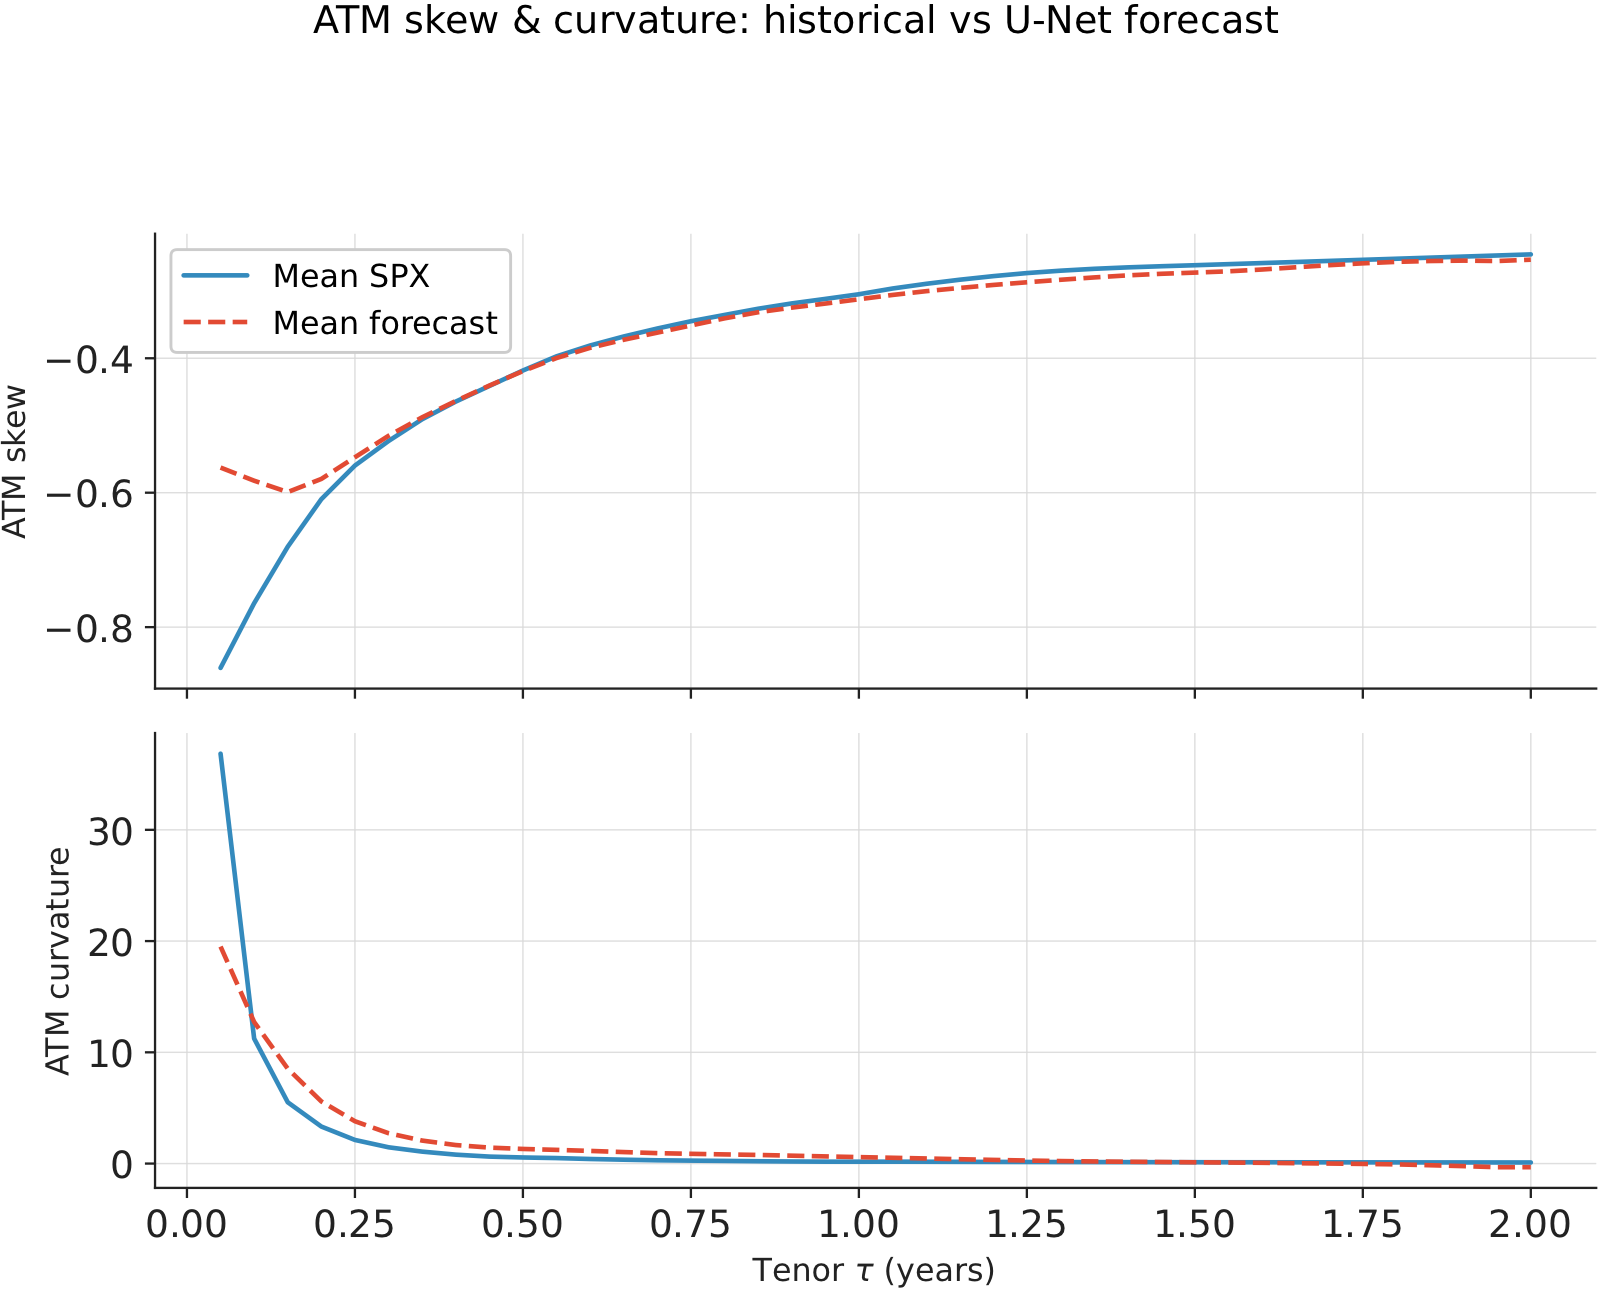

In [6]:
from implied_volatility_diffusion.core.atm_geometry import atm_skew_and_curvature

tau_axis = GRID.tau.astype(np.float64)
hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
if not hist_insts:
    raise RuntimeError("no historical instances available")

mean_gt = np.nanmean(
    np.stack([np.asarray(inst["ground_truth"], dtype=np.float64) for inst in hist_insts], axis=0),
    axis=0,
)
mean_fc = np.nanmean(
    np.stack([np.asarray(inst["forecast"], dtype=np.float64) for inst in hist_insts], axis=0),
    axis=0,
)
_, sk_gt, cu_gt = atm_skew_and_curvature(mean_gt, GRID)
_, sk_fc, cu_fc = atm_skew_and_curvature(mean_fc, GRID)


fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])
ax0.plot(tau_axis, sk_gt, label="Mean SPX", color=TENOR_COLORS[0])
ax0.plot(tau_axis, sk_fc, "--", label="Mean forecast", color=TENOR_COLORS[1])
ax0.set_ylabel(r"ATM skew") 
ax0.legend(loc="best")

ax1.plot(tau_axis, cu_gt, color=TENOR_COLORS[0], label="Mean SPX")
ax1.plot(tau_axis, cu_fc, "--", color=TENOR_COLORS[1], label="Mean forecast")
ax1.set_xlabel(r"Tenor $\tau$ (years)")
ax1.set_ylabel(r"ATM curvature")

fig.suptitle("ATM skew & curvature: historical vs U-Net forecast", y=1.06)
style_2d_axes(ax0)
style_2d_axes(ax1)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
fig.savefig("unet_vqvae_atm_skew_and_curvature.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Model forecast on the largest historical IV jump


In [7]:
if not HARD_HIST_AVAILABLE:
    print("Skipping model comparison: no historical validation pairs.")
else:
    HARD_JUMP_FORECAST_SEED = int(VALIDATION_SEED + 7700)
    hard_forecast, hard_forecast_raw, hard_meta = _conditional_forecast(HARD_S_CURR, HARD_JUMP_FORECAST_SEED)
    hard_raw_m = _forecast_vs_gt_metrics(hard_forecast_raw, HARD_S_NEXT)
    hard_rep_m = _forecast_vs_gt_metrics(hard_forecast, HARD_S_NEXT)
    hard_delta_m = _repair_delta_metrics(hard_forecast_raw, hard_forecast)
    hard_rmse = hard_rep_m["rmse"]
    hard_mae = hard_rep_m["mae"]
    print("Largest historical IV jump — forecast metrics vs GT:")
    print(
        f"  Unrepaired: RMSE={hard_raw_m['rmse']:.6f}  MAE={hard_raw_m['mae']:.6f}  "
        f"arb_free={hard_meta['forecast_raw_arb_free']}"
    )
    print(
        f"  Repaired:   RMSE={hard_rep_m['rmse']:.6f}  MAE={hard_rep_m['mae']:.6f}  "
        f"arb_free={hard_meta['forecast_arb_free']}  seed={hard_meta['seed']}"
    )
    print(
        f"  Repair Δ:   RMSE={hard_delta_m['repair_rmse']:.6f}  MAE={hard_delta_m['repair_mae']:.6f}  "
        f"max|Δ|={hard_delta_m['repair_max_abs']:.6f}"
    )
    print(
        f"  Realized jump (GT − prev) RMS={HARD_HIST_JUMP_RMSE:.6f} — "
        "forecast error measures how well the model predicts that move from $S_t$."
    )

    m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
    tau_axis = np.asarray(GRID.tau, dtype=np.float64)
    MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

    inst = {
        "input": HARD_S_CURR,
        "ground_truth": HARD_S_NEXT,
        "forecast": hard_forecast,
        "input_label": f"date={HARD_HIST_DATE_CURR.date()}",
        "gt_label": f"date={HARD_HIST_DATE_NEXT.date()}",
    }

    with rc_context():
        from matplotlib.ticker import FormatStrFormatter

        fig3d = plt.figure(figsize=(26.0, 5.8))
        fig3d.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

        path_label = "Historical (largest IV jump)"
        panels = [
            (
                inst["input"],
                f"Input ($S_t$): {inst['input_label']}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                inst["ground_truth"],
                f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (inst["forecast"], "Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (
                inst["forecast"] - inst["ground_truth"],
                "Error (Forecast $-$ GT)",
                DIFF_CMAP,
                r"$\Delta\sigma$",
                True,
            ),
        ]

        all_iv_vals = np.concatenate(
            [
                inst["input"][:, tenor_idx].ravel(),
                inst["ground_truth"][:, tenor_idx].ravel(),
                inst["forecast"][:, tenor_idx].ravel(),
            ]
        )
        shared_vmin = float(np.nanmin(all_iv_vals))
        shared_vmax = float(np.nanmax(all_iv_vals))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
            ax = fig3d.add_subplot(1, 4, col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
            ax.set_xlabel(r"m", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel(zlabel, labelpad=6)
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            style_3d_axes(ax)
            ax.xaxis.pane.set_edgecolor("0.85")
            ax.yaxis.pane.set_edgecolor("0.85")
            ax.zaxis.pane.set_edgecolor("0.85")
            cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.ax.tick_params(labelsize=7)

        plt.show()

        repair_panels = [
            (
                hard_forecast_raw,
                f"Unrepaired\nRMSE={hard_raw_m['rmse']:.3f}  arb={hard_meta.get('forecast_raw_arb_free', False)}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                hard_forecast,
                f"Repaired\nRMSE={hard_rep_m['rmse']:.3f}  arb={hard_meta['forecast_arb_free']}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                hard_forecast - hard_forecast_raw,
                f"Repair Δ\nRMSE={hard_delta_m['repair_rmse']:.3f}",
                DIFF_CMAP,
                r"$\Delta\sigma$",
                True,
            ),
        ]
        all_fc = np.concatenate([hard_forecast_raw[:, tenor_idx].ravel(), hard_forecast[:, tenor_idx].ravel()])
        fc_vmin = float(np.nanmin(all_fc))
        fc_vmax = float(np.nanmax(all_fc))
        if (not np.isfinite(fc_vmin)) or (not np.isfinite(fc_vmax)) or fc_vmin == fc_vmax:
            fc_vmin, fc_vmax = 0.0, 1.0

        fig3d_repair = plt.figure(figsize=(22.0, 5.8))
        fig3d_repair.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d_repair.subplots_adjust(wspace=0.28, hspace=0.35)
        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(repair_panels):
            ax = fig3d_repair.add_subplot(1, 3, col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = fc_vmin, fc_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
            ax.set_xlabel(r"m", labelpad=8)
            ax.set_ylabel(r"$	au$ (years)", labelpad=10)
            ax.set_zlabel("")
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            style_3d_axes(ax)
            ax.set_zticklabels([])
            cbar = fig3d_repair.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.set_label(zlabel)
            cbar.ax.tick_params(labelsize=7)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

        plt.show()

Largest historical IV jump — forecast metrics vs GT:
  Unrepaired: RMSE=0.029123  MAE=0.020828  arb_free=False
  Repaired:   RMSE=0.029522  MAE=0.021290  arb_free=True  seed=7742
  Repair Δ:   RMSE=0.005156  MAE=0.001732  max|Δ|=0.060993
  Realized jump (GT − prev) RMS=0.035449 — forecast error measures how well the model predicts that move from $S_t$.


<ipython-input-7-1cdffcf6c56c>:125:   plt.show()
<ipython-input-7-1cdffcf6c56c>:198:   plt.show()


## No-arbitrage diagnostics

In [8]:
def _report_row(kind, instance, path_type, label, iv):
    strict = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_DIAG_TOL)
    soft = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_ACCEPT_TOL)
    return {
        "instance": instance,
        "path_type": path_type,
        "kind": kind,
        "label": label,
        "strict_arb_free": bool(strict.arbitrage_free),
        "soft_arb_free": bool(soft.arbitrage_free),
        "worst_butterfly": float(strict.worst_butterfly),
        "worst_calendar": float(strict.worst_calendar),
        "worst_bound": float(strict.worst_bound),
        "n_butterfly": int(strict.n_butterfly_violations),
        "n_calendar": int(strict.n_calendar_violations),
        "n_bound": int(strict.n_bound_violations),
    }


validation_rows = []
for i, inst in enumerate(display_instances, start=1):
    path_type = str(inst["path_type"])
    validation_rows.append(
        _report_row(f"input ($S_t$): {inst['input_label']}", i, path_type, inst["input_label"], inst["input"])
    )
    validation_rows.append(
        _report_row(
            f"ground truth ($S_{{t+1}}$): {inst['gt_label']}", i, path_type, inst["gt_label"], inst["ground_truth"]
        )
    )
    validation_rows.append(
        _report_row(
            "forecast (unrepaired)",
            i,
            path_type,
            f"forecast raw (seed={inst['meta']['seed']})",
            inst["forecast_raw"],
        )
    )
    validation_rows.append(
        _report_row(
            "forecast (repaired)",
            i,
            path_type,
            f"forecast repaired (seed={inst['meta']['seed']})",
            inst["forecast"],
        )
    )

surface_validation_df = pd.DataFrame(validation_rows)

if "forecast_repair_metrics_df" not in globals():
    raise RuntimeError("Run the Conditional forecast cell first (builds forecast_repair_metrics_df).")

display(
    forecast_repair_metrics_df[
        [
            "instance",
            "path_type",
            "raw_arb_free",
            "repaired_arb_free",
            "raw_rmse_vs_gt",
            "repaired_rmse_vs_gt",
            "rmse_delta_repaired_minus_raw",
            "raw_mae_vs_gt",
            "repaired_mae_vs_gt",
            "repair_rmse",
            "repair_max_abs",
        ]
    ].rename(
        columns={
            "raw_arb_free": "unrepaired_arb_free",
            "repaired_arb_free": "repaired_arb_free",
            "raw_rmse_vs_gt": "unrepaired_rmse",
            "repaired_rmse_vs_gt": "repaired_rmse",
            "rmse_delta_repaired_minus_raw": "rmse_change",
            "raw_mae_vs_gt": "unrepaired_mae",
            "repaired_mae_vs_gt": "repaired_mae",
            "repair_rmse": "repair_magnitude_rmse",
            "repair_max_abs": "repair_max_abs",
        }
    )
)

forecast_error_rows = []
for i, inst in enumerate(instances, start=1):
    gt = inst["ground_truth"]
    for variant, fc in (("unrepaired", inst["forecast_raw"]), ("repaired", inst["forecast"])):
        diff = fc - gt
        diff_5 = diff[:, tenor_idx]
        gt_abs = np.abs(np.asarray(gt, dtype=float))
        mape_mask = np.isfinite(diff) & np.isfinite(gt) & (gt_abs > float(IV_FLOOR_SAMPLE))
        mape_pct = (
            float(100.0 * np.mean(np.abs(diff[mape_mask]) / gt_abs[mape_mask])) if np.any(mape_mask) else float("nan")
        )
        forecast_error_rows.append(
            {
                "instance": i,
                "path_type": inst["path_type"],
                "forecast_variant": variant,
                "input_label": inst["input_label"],
                "gt_label": inst["gt_label"],
                "forecast_seed": int(inst["meta"]["seed"]),
                "mean_error": float(np.nanmean(diff)),
                "mae": float(np.nanmean(np.abs(diff))),
                "rmse": float(np.sqrt(np.nanmean(diff * diff))),
                "mape_pct": mape_pct,
                "max_abs_error": float(np.nanmax(np.abs(diff))),
                "rmse_on_plotted_tenors": float(np.sqrt(np.nanmean(diff_5 * diff_5))),
            }
        )

forecast_error_df = pd.DataFrame(forecast_error_rows)

,instance,path_type,unrepaired_arb_free,repaired_arb_free,unrepaired_rmse,repaired_rmse,rmse_change,unrepaired_mae,repaired_mae,repair_magnitude_rmse,repair_max_abs
0,1,historical,False,True,0.017389,0.017337,-0.000052,0.015345,0.015398,0.002382,0.055242
1,2,historical,False,True,0.017964,0.017722,-0.000243,0.011914,0.011899,0.001103,0.022905
2,3,historical,False,True,0.016232,0.014651,-0.001581,0.008167,0.007881,0.006377,0.115278
3,4,historical,False,True,0.006430,0.005711,-0.000719,0.004090,0.003940,0.002803,0.050972
4,5,historical,False,True,0.010631,0.009672,-0.000960,0.005021,0.005031,0.003026,0.034434
...,...,...,...,...,...,...,...,...,...,...,...
246,247,historical,False,True,0.008805,0.007911,-0.000894,0.004464,0.004162,0.002839,0.040541
247,248,historical,False,True,0.019648,0.017719,-0.001929,0.011210,0.010650,0.005891,0.067286
248,249,historical,False,True,0.003580,0.005168,0.001588,0.002272,0.002583,0.003994,0.065954
249,250,sabr,True,True,0.000629,0.000629,0.000000,0.000502,0.000502,0.000000,0.000000


## IV surface moments (historic input, ground truth, and forecasts)

Pooled and per-instance summary statistics over all finite grid cells: mean, standard deviation, minimum, median, maximum, skewness, and excess kurtosis.


In [9]:
from scipy import stats as scipy_stats

_MOMENT_COLS = ("mean", "std", "min", "median", "max", "skewness", "excess_kurtosis")
_SURFACE_SPECS = (
    ("historic_input", "input"),
    ("ground_truth", "ground_truth"),
    ("forecast_repaired", "forecast"),
    ("forecast_raw", "forecast_raw"),
)


def _finite_iv_stats(iv: np.ndarray) -> dict:
    v = np.asarray(iv, dtype=np.float64).ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        nan = float("nan")
        return {
            "n": 0,
            "mean": nan,
            "std": nan,
            "min": nan,
            "median": nan,
            "max": nan,
            "skewness": nan,
            "excess_kurtosis": nan,
        }
    return {
        "n": int(v.size),
        "mean": float(np.mean(v)),
        "std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
        "min": float(np.min(v)),
        "median": float(np.median(v)),
        "max": float(np.max(v)),
        "skewness": float(scipy_stats.skew(v, bias=False)) if v.size > 2 else float("nan"),
        "excess_kurtosis": (
            float(scipy_stats.kurtosis(v, fisher=True, bias=False)) if v.size > 3 else float("nan")
        ),
    }


def _surface_moment_row(*, scope: str, instance, path_type: str, surface: str, iv: np.ndarray) -> dict:
    row = {
        "scope": scope,
        "instance": instance,
        "path_type": path_type,
        "surface": surface,
    }
    row.update(_finite_iv_stats(iv))
    return row


def _moments_table_for_instances(scope: str, inst_list: list, *, instance_key) -> pd.DataFrame:
    rows = []
    for inst in inst_list:
        instance = instance_key(inst)
        path_type = str(inst["path_type"])
        for surface_label, iv_key in _SURFACE_SPECS:
            rows.append(
                _surface_moment_row(
                    scope=scope,
                    instance=instance,
                    path_type=path_type,
                    surface=surface_label,
                    iv=inst[iv_key],
                )
            )
    cols = ["scope", "instance", "path_type", "surface", "n", *_MOMENT_COLS]
    return pd.DataFrame(rows, columns=cols) if rows else pd.DataFrame(columns=cols)


iv_hist_instances = [inst for inst in instances if inst["path_type"] == "historical"]

iv_surface_moments_df = _moments_table_for_instances(
    "display_instance",
    display_instances,
    instance_key=lambda inst: int(display_instances.index(inst)) + 1,
)
display(iv_surface_moments_df)

if iv_hist_instances:
    iv_hist_gt_eval = np.concatenate([inst["ground_truth"].ravel() for inst in iv_hist_instances])
    iv_hist_fc_eval = np.concatenate([inst["forecast"].ravel() for inst in iv_hist_instances])
    iv_hist_in_eval = np.concatenate([inst["input"].ravel() for inst in iv_hist_instances])
    iv_hist_fc_raw_eval = np.concatenate([inst["forecast_raw"].ravel() for inst in iv_hist_instances])

    iv_surface_moments_hist_pooled_df = pd.DataFrame(
        [
            _surface_moment_row(
                scope="historical_pooled",
                instance="all",
                path_type="historical",
                surface=surface_label,
                iv=iv,
            )
            for surface_label, iv in (
                ("historic_input", iv_hist_in_eval),
                ("ground_truth", iv_hist_gt_eval),
                ("forecast_repaired", iv_hist_fc_eval),
                ("forecast_raw", iv_hist_fc_raw_eval),
            )
        ]
    )
    display(iv_surface_moments_hist_pooled_df)

    iv_surface_moments_hist_by_instance_df = _moments_table_for_instances(
        "historical_instance",
        iv_hist_instances,
        instance_key=lambda inst: int(instances.index(inst)) + 1,
    )
else:
    display(iv_surface_moments_hist_by_instance_df)

    iv_hist_gt_eval = np.array([], dtype=np.float64)
    iv_hist_fc_eval = np.array([], dtype=np.float64)
    iv_surface_moments_hist_pooled_df = pd.DataFrame()
    iv_surface_moments_hist_by_instance_df = pd.DataFrame()
    print("No historical instances in `instances`; skipping pooled / per-instance moment tables.")


,scope,instance,path_type,surface,n,mean,std,min,median,max,skewness,excess_kurtosis
0,display_instance,1,historical,historic_input,1640,0.216908,0.082537,0.110182,0.195508,0.626348,0.963230,0.802652
1,display_instance,1,historical,ground_truth,1640,0.219272,0.082823,0.118229,0.200216,0.653004,1.072979,1.443536
2,display_instance,1,historical,forecast_repaired,1640,0.230584,0.085017,0.133811,0.210728,0.678426,1.093781,1.494813
3,display_instance,1,historical,forecast_raw,1640,0.230257,0.085774,0.132534,0.210610,0.704582,1.143054,1.821323
4,display_instance,2,sabr,historic_input,1640,0.046265,0.007455,0.037140,0.044697,0.064977,0.751295,-0.444420
5,display_instance,2,sabr,ground_truth,1640,0.046739,0.007458,0.037642,0.045133,0.065487,0.760102,-0.433282
6,display_instance,2,sabr,forecast_repaired,1640,0.046876,0.007619,0.035161,0.045547,0.065413,0.668344,-0.558874
7,display_instance,2,sabr,forecast_raw,1640,0.046876,0.007619,0.035161,0.045547,0.065413,0.668344,-0.558874
8,display_instance,3,heston,historic_input,1640,0.349716,0.032154,0.316173,0.337327,0.460720,1.229457,0.680699
9,display_instance,3,heston,ground_truth,1640,0.357840,0.035627,0.320182,0.344216,0.475166,1.164235,0.438380


,scope,instance,path_type,surface,n,mean,std,min,median,max,skewness,excess_kurtosis
0,historical_pooled,all,historical,historic_input,408360,0.211031,0.083813,0.067088,0.191178,0.950862,1.335157,3.192304
1,historical_pooled,all,historical,ground_truth,408360,0.210878,0.083864,0.067088,0.190914,0.950862,1.337597,3.198730
2,historical_pooled,all,historical,forecast_repaired,408360,0.214587,0.082153,0.079784,0.195311,0.936585,1.295688,2.796007
3,historical_pooled,all,historical,forecast_raw,408360,0.213903,0.082984,0.072530,0.194250,0.964365,1.350971,3.220946


In [10]:
_iv_dist_gt_eval = np.asarray(iv_hist_gt_eval, dtype=np.float64).ravel()
_iv_dist_gt_eval = _iv_dist_gt_eval[np.isfinite(_iv_dist_gt_eval)]
_iv_dist_fc_eval = np.asarray(iv_hist_fc_eval, dtype=np.float64).ravel()
_iv_dist_fc_eval = _iv_dist_fc_eval[np.isfinite(_iv_dist_fc_eval)]

if _iv_dist_gt_eval.size and _iv_dist_fc_eval.size:
    _iv_dist_combined = np.concatenate([_iv_dist_gt_eval, _iv_dist_fc_eval])
    _iv_dist_lo, _iv_dist_hi = np.percentile(_iv_dist_combined, [0.5, 99.5])
    if not np.isfinite(_iv_dist_lo) or not np.isfinite(_iv_dist_hi) or _iv_dist_lo >= _iv_dist_hi:
        _iv_dist_lo, _iv_dist_hi = float(np.min(_iv_dist_combined)), float(np.max(_iv_dist_combined))
    if _iv_dist_lo >= _iv_dist_hi:
        _iv_dist_hi = _iv_dist_lo + 1e-6
    _iv_dist_bins = np.linspace(_iv_dist_lo, _iv_dist_hi, 72)

    _fig_iv_dist, _ax_iv_dist = plt.subplots(figsize=(9.5, 4.8))
    _fig_iv_dist.patch.set_facecolor(plt.rcParams["figure.facecolor"])
    _ax_iv_dist.hist(
        _iv_dist_gt_eval,
        bins=_iv_dist_bins,
        density=True,
        alpha=0.45,
        color="#2563eb",
        label="Ground truth $S_{t+1}$ (historical path)",
        histtype="stepfilled",
        edgecolor="none",
    )
    _ax_iv_dist.hist(
        _iv_dist_fc_eval,
        bins=_iv_dist_bins,
        density=True,
        alpha=0.45,
        color="#ea580c",
        label="Forecast",
        histtype="stepfilled",
        edgecolor="none",
    )
    _ax_iv_dist.set_xlabel(r"Implied volatility $\sigma_{\mathrm{imp}}$")
    _ax_iv_dist.set_ylabel("Density")
    _ax_iv_dist.set_title("Historical path: ground truth vs forecast")
    _ax_iv_dist.legend(loc="upper right", frameon=True)
    style_2d_axes(_ax_iv_dist)
    _fig_iv_dist.tight_layout()
    plt.show()
else:
    print("Skipping IV histogram: run the IV statistics cell first, or missing historical GT/forecast samples.")

<ipython-input-10-8ed260c298b9>:43:   plt.show()


## Model forecast

<ipython-input-11-884f5797b67b>:98:   plt.show()
<ipython-input-11-884f5797b67b>:98:   plt.show()


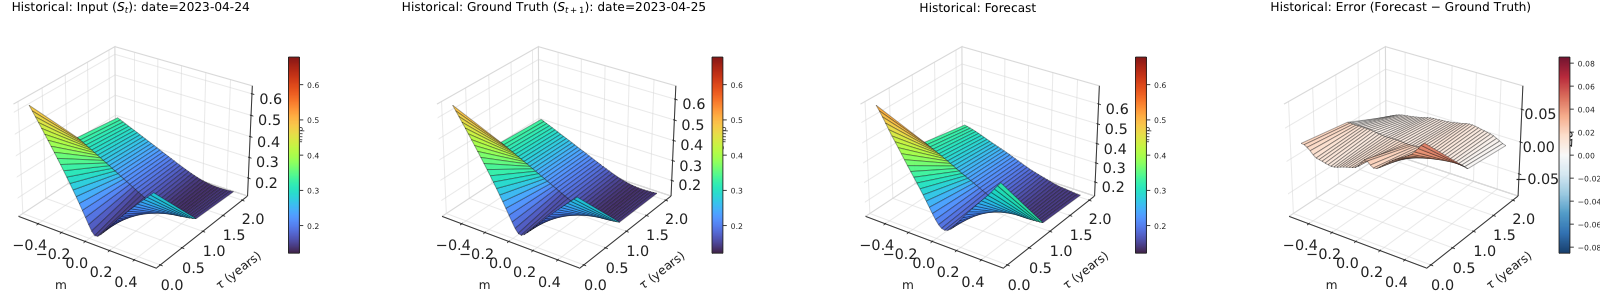

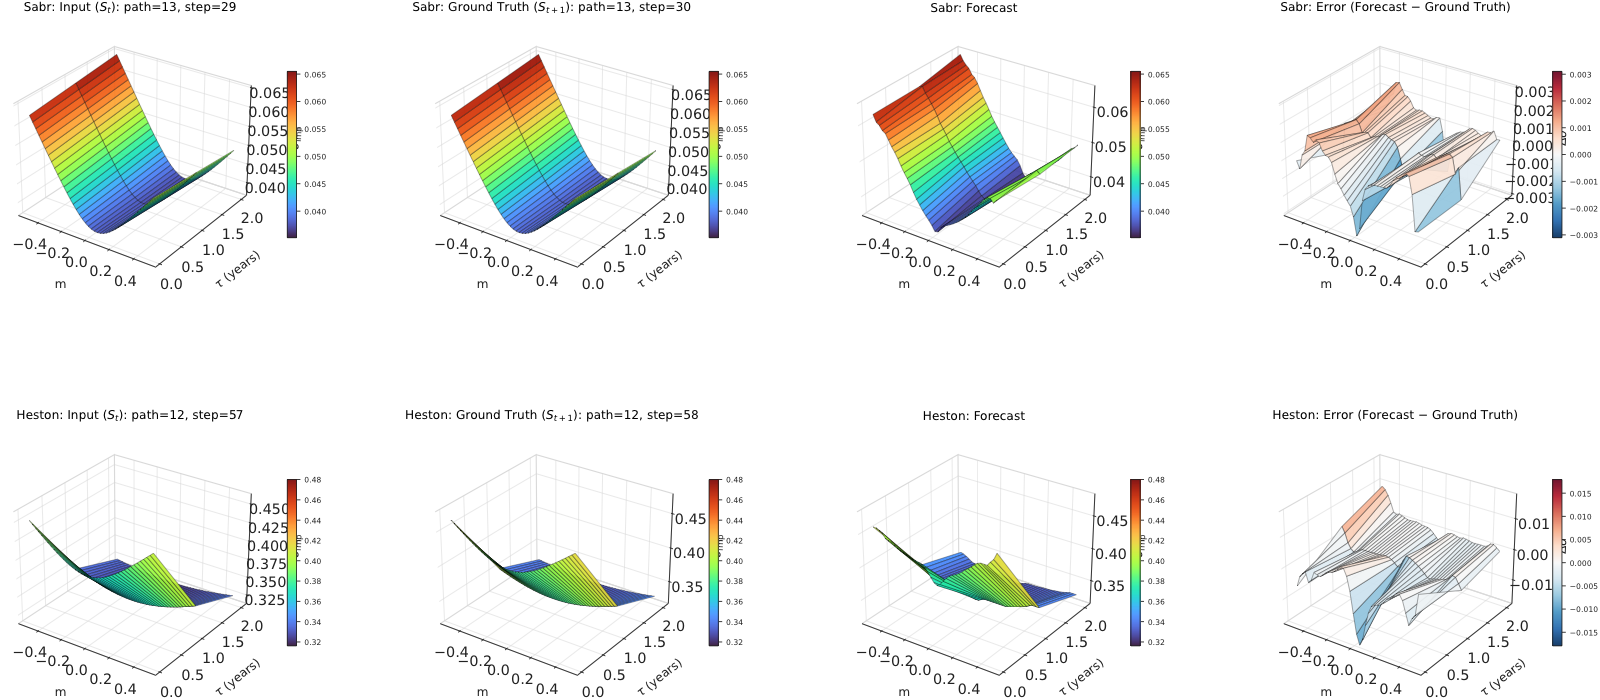

In [11]:
m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
tau_axis = np.asarray(GRID.tau, dtype=np.float64)
MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

_VALIDATION_PDF_GROUPS = (
    ("historical", [inst for inst in display_instances if inst["path_type"] == "historical"]),
    ("synthetic", [inst for inst in display_instances if inst["path_type"] != "historical"]),
)

for _pdf_group_label, _group_instances in _VALIDATION_PDF_GROUPS:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig3d = plt.figure(figsize=(26.0, 5.8 * n_instances))
        fig3d.patch.set_facecolor(plt.rcParams["figure.facecolor"])
        fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

        for row, inst in enumerate(_group_instances):
            path_label = inst["path_type"].capitalize()
            panels = [
                (inst["input"], f"Input ($S_t$): {inst['input_label']}", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (
                    inst["ground_truth"],
                    f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                    SURF_CMAP,
                    r"$\sigma_{\mathrm{imp}}$",
                    False,
                ),
                (inst["forecast"], "Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (
                    inst["forecast"] - inst["ground_truth"],
                    "Error (Forecast $-$ Ground Truth)",
                    DIFF_CMAP,
                    r"$\Delta\sigma$",
                    True,
                ),
            ]

            all_iv_vals = np.concatenate(
                [
                    inst["input"][:, tenor_idx].ravel(),
                    inst["ground_truth"][:, tenor_idx].ravel(),
                    inst["forecast"][:, tenor_idx].ravel(),
                ]
            )
            shared_vmin = float(np.nanmin(all_iv_vals))
            shared_vmax = float(np.nanmax(all_iv_vals))
            if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
                shared_vmin, shared_vmax = 0.0, 1.0

            for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
                ax = fig3d.add_subplot(n_instances, 4, 4 * row + col + 1, projection="3d")
                iv_5 = iv[:, tenor_idx]
                if is_diff:
                    panel_abs = float(np.nanmax(np.abs(iv_5)))
                    if not np.isfinite(panel_abs) or panel_abs == 0.0:
                        panel_abs = 1.0
                    vmin_, vmax_ = -panel_abs, panel_abs
                    ax.set_zlim(vmin_, vmax_)
                else:
                    vmin_, vmax_ = shared_vmin, shared_vmax

                plotted = ax.plot_surface(
                    MM_5,
                    TT_5,
                    iv_5,
                    cmap=cmap,
                    vmin=vmin_,
                    vmax=vmax_,
                    linewidth=0.3,
                    edgecolor="k",
                    alpha=0.92,
                    antialiased=True,
                    rstride=1,
                    cstride=1,
                )
                ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
                ax.set_xlabel(r"m", labelpad=8)
                ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
                ax.set_zlabel(zlabel, labelpad=6)
                ax.view_init(elev=28, azim=-55)
                ax.tick_params(pad=2)
                style_3d_axes(ax)
                ax.xaxis.pane.set_edgecolor("0.85")
                ax.yaxis.pane.set_edgecolor("0.85")
                ax.zaxis.pane.set_edgecolor("0.85")

                cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
                cbar.ax.tick_params(labelsize=7)

        fig3d.savefig(
            f"unet_vqvae_input_gt_forecast_3d_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()


## Forecast: unrepaired vs repaired (metrics + 3D)

<ipython-input-12-bdd43fa6ca25>:112:   plt.show()


,instance,path_type,pair_idx,seed,raw_arb_free,repaired_arb_free,raw_rmse_vs_gt,repaired_rmse_vs_gt,rmse_delta_repaired_minus_raw,raw_mae_vs_gt,repaired_mae_vs_gt,raw_mape_pct_vs_gt,repaired_mape_pct_vs_gt,repair_rmse,repair_mae,repair_max_abs,raw_worst_butterfly,raw_worst_calendar,repaired_worst_butterfly,repaired_worst_calendar
0,1,historical,0,9042,False,True,0.017389,0.017337,-0.000052,0.015345,0.015398,6.473214,6.532286,0.002382,0.000466,0.055242,-3.509459e-02,-0.001922,-5.602006e-15,-3.488255e-05
1,2,historical,1,9043,False,True,0.017964,0.017722,-0.000243,0.011914,0.011899,4.313500,4.331844,0.001103,0.000389,0.022905,-3.366372e-02,-0.001658,-9.057471e-15,-5.423777e-05
2,3,historical,2,9044,False,True,0.016232,0.014651,-0.001581,0.008167,0.007881,3.047914,3.028855,0.006377,0.001181,0.115278,-2.084239e-02,-0.000814,-3.780959e-15,-6.104482e-05
3,4,historical,3,9045,False,True,0.006430,0.005711,-0.000719,0.004090,0.003940,1.636254,1.606119,0.002803,0.000762,0.050972,-1.942171e-02,-0.001610,-3.780959e-15,-5.204170e-17
4,5,historical,4,9046,False,True,0.010631,0.009672,-0.000960,0.005021,0.005031,2.055280,2.104831,0.003026,0.000967,0.034434,-3.291798e-02,-0.002073,-7.561918e-15,-3.730200e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,historical,246,9288,False,True,0.008805,0.007911,-0.000894,0.004464,0.004162,2.064253,1.944073,0.002839,0.000869,0.040541,-6.070699e-02,-0.000605,-3.780959e-15,-6.879925e-06
247,248,historical,247,9289,False,True,0.019648,0.017719,-0.001929,0.011210,0.010650,5.439185,5.405083,0.005891,0.001851,0.067286,-5.073665e-02,-0.000995,-7.561918e-15,-9.371035e-05
248,249,historical,248,9290,False,True,0.003580,0.005168,0.001588,0.002272,0.002583,1.101707,1.221839,0.003994,0.001494,0.065954,-6.413123e-02,-0.001238,-7.015520e-15,-7.561195e-05
249,250,sabr,29,29071,True,True,0.000629,0.000629,0.000000,0.000502,0.000502,1.081423,1.081423,0.000000,0.000000,0.000000,-3.780959e-15,-0.000010,-3.780959e-15,-1.006215e-05


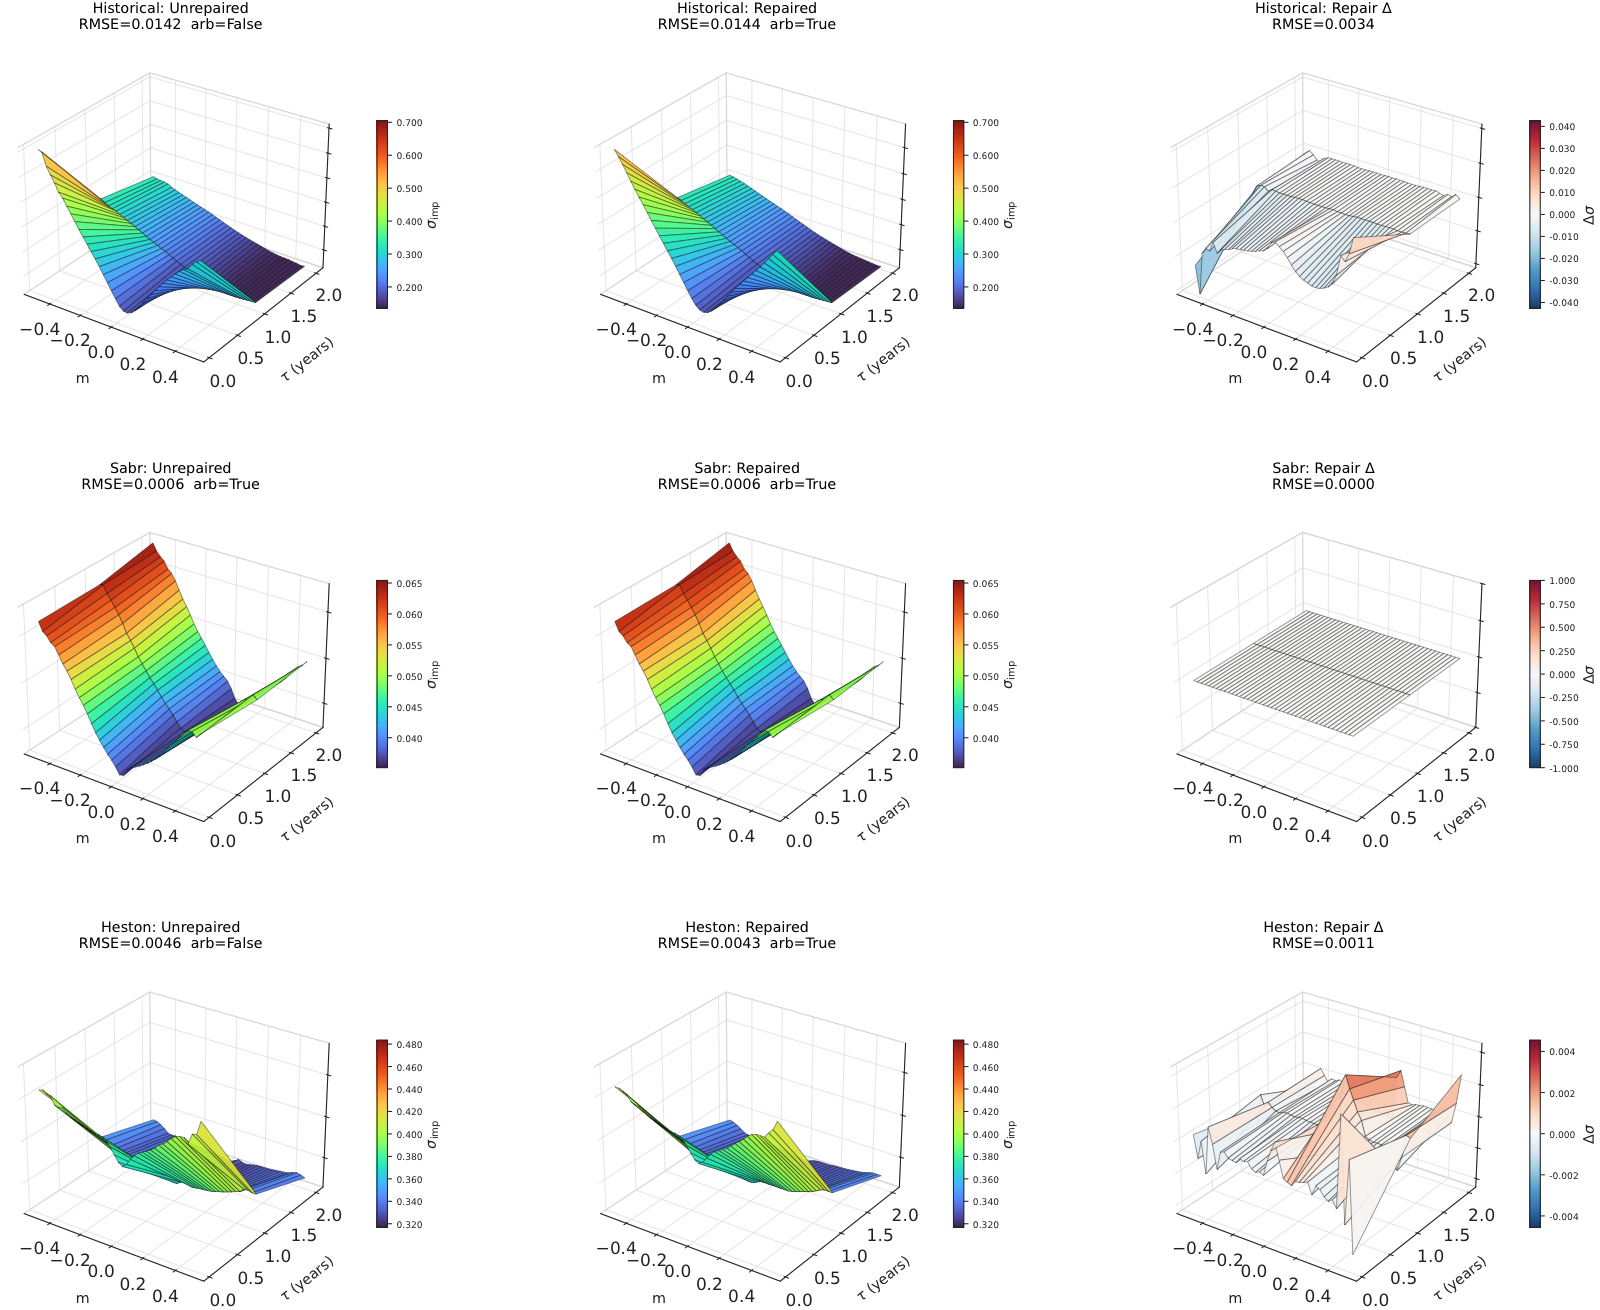

In [12]:
if "forecast_repair_metrics_df" not in globals():
    raise RuntimeError("Run the Conditional forecast cell first (builds forecast_repair_metrics_df).")

display(forecast_repair_metrics_df)

m_axis = np.asarray(GRID.log_moneyness, dtype=np.float64)
tau_axis = np.asarray(GRID.tau, dtype=np.float64)
MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

_repair_instances = list(display_instances)
if not _repair_instances:
    raise RuntimeError("No display instances available for repair comparison.")

n_instances = len(_repair_instances)

with rc_context():
    from matplotlib.ticker import FormatStrFormatter

    fig3d = plt.figure(figsize=(22.0, 5.8 * n_instances))
    fig3d.patch.set_facecolor(plt.rcParams["figure.facecolor"])
    fig3d.subplots_adjust(wspace=0.28, hspace=0.35)

    for row, inst in enumerate(_repair_instances):
        fc_raw = np.asarray(inst["forecast_raw"], dtype=np.float64)
        fc_rep = np.asarray(inst["forecast"], dtype=np.float64)
        repair_delta = fc_rep - fc_raw
        path_label = inst["path_type"].capitalize()
        raw_arb = bool(inst["meta"].get("forecast_raw_arb_free", False))
        rep_arb = bool(inst["meta"]["forecast_arb_free"])
        mrow = forecast_repair_metrics_df[
            (forecast_repair_metrics_df["path_type"] == inst["path_type"])
            & (forecast_repair_metrics_df["pair_idx"] == int(inst["pair_idx"]))
        ].iloc[0]

        panels = [
            (
                fc_raw,
                f"Unrepaired\nRMSE={mrow['raw_rmse_vs_gt']:.4f}  arb={raw_arb}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                fc_rep,
                f"Repaired\nRMSE={mrow['repaired_rmse_vs_gt']:.4f}  arb={rep_arb}",
                SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                repair_delta,
                f"Repair Δ\nRMSE={mrow['repair_rmse']:.4f}",
                DIFF_CMAP,
                r"$\Delta\sigma$",
                True,
            ),
        ]

        all_iv_vals = np.concatenate([fc_raw[:, tenor_idx].ravel(), fc_rep[:, tenor_idx].ravel()])
        shared_vmin = float(np.nanmin(all_iv_vals))
        shared_vmax = float(np.nanmax(all_iv_vals))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
            ax = fig3d.add_subplot(n_instances, 3, 3 * row + col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, pad=12)
            ax.set_xlabel(r"m", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel("")
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            style_3d_axes(ax)
            ax.set_zticklabels([])
            ax.xaxis.pane.set_edgecolor("0.85")
            ax.yaxis.pane.set_edgecolor("0.85")
            ax.zaxis.pane.set_edgecolor("0.85")
            cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.set_label(zlabel)
            cbar.ax.tick_params(labelsize=7)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    fig3d.savefig(
        "unet_vqvae_unrepaired_vs_repaired_3d.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()


In [13]:
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}".replace(".", ",")))

<ipython-input-14-5cea1ef2b77c>:88:   plt.show()
<ipython-input-14-5cea1ef2b77c>:88:   plt.show()


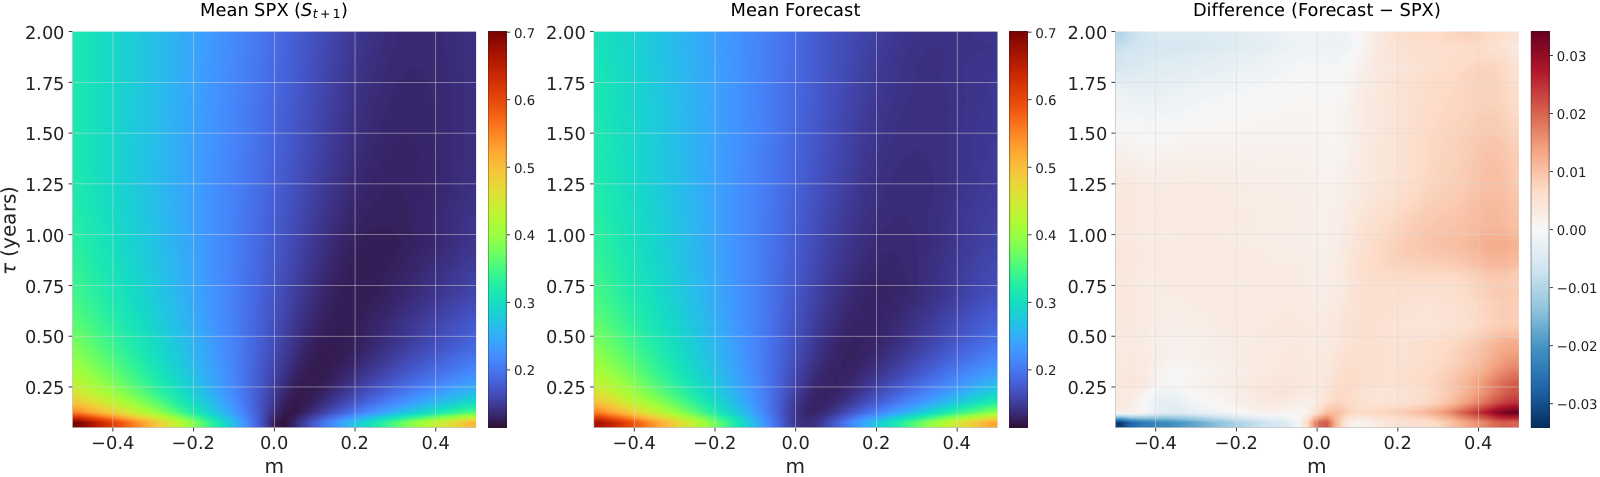

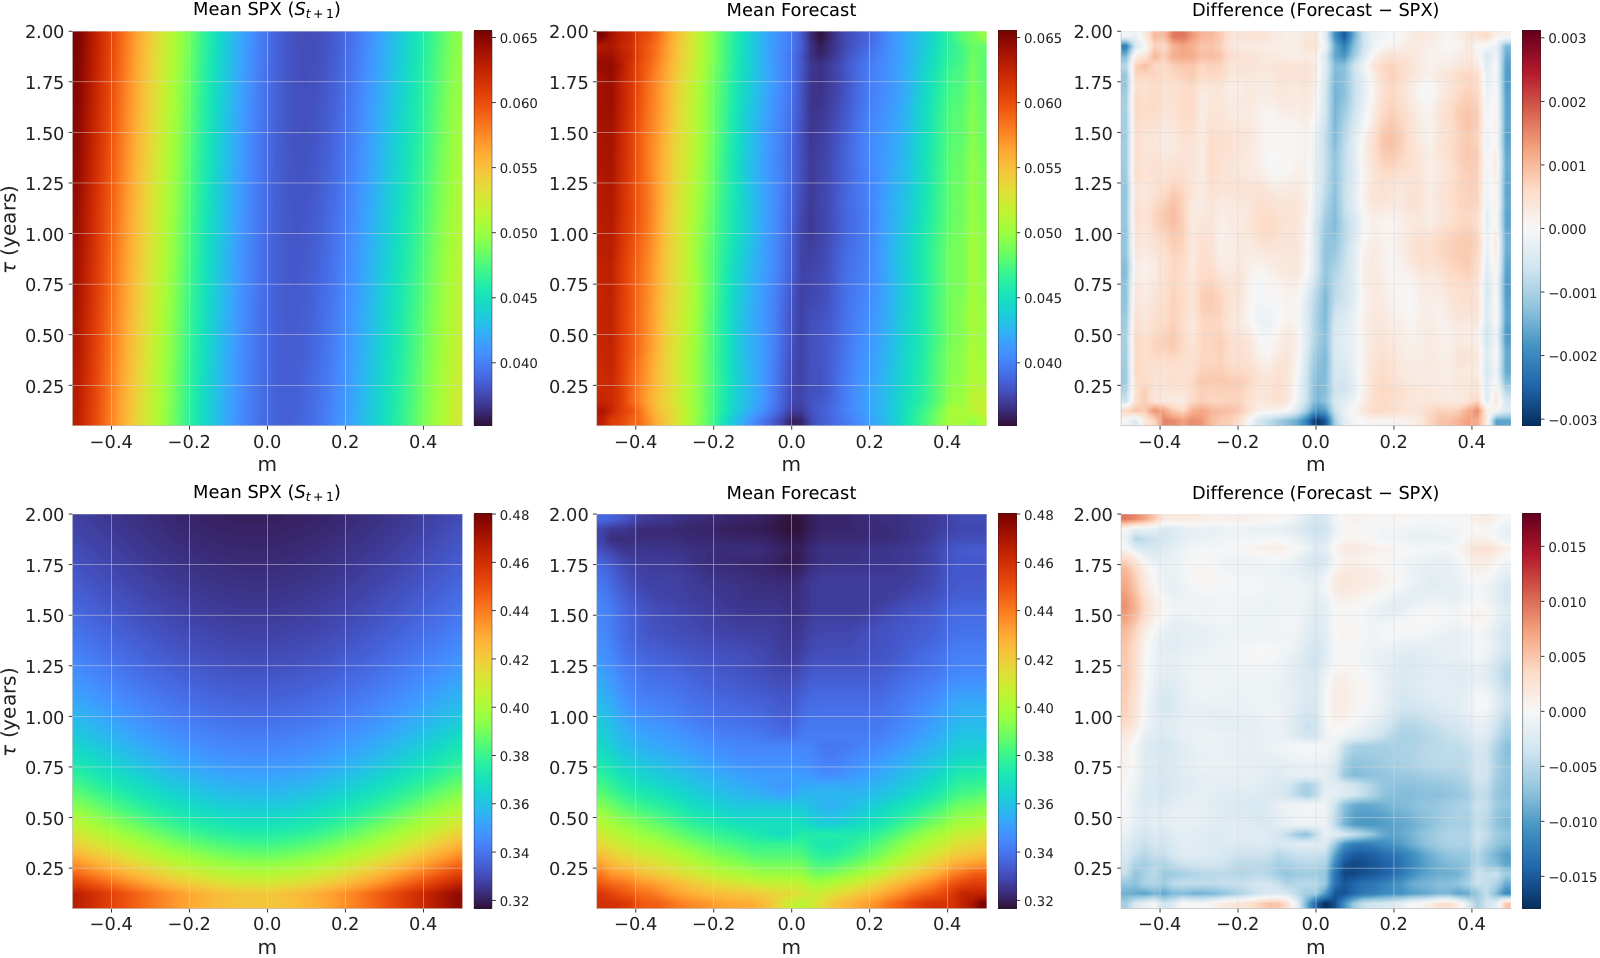

In [14]:
_hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
_synth_insts = [inst for inst in display_instances if inst["path_type"] != "historical"]

m_ticks = np.arange(np.ceil(m_axis[0] / 0.2) * 0.2, m_axis[-1] + 1e-9, 0.2)  # every 0.5 instead of 0.25

_heatmap_groups = []
if _hist_insts:
    mean_gt = np.nanmean(np.stack([inst["ground_truth"] for inst in _hist_insts]), axis=0)
    mean_fc = np.nanmean(np.stack([inst["forecast"] for inst in _hist_insts]), axis=0)
    _heatmap_groups.append(("historical", [{"ground_truth": mean_gt, "forecast": mean_fc,
        "path_type": "historical", "gt_label": f"mean over {len(_hist_insts)} pairs",
        "input_label": f"mean over {len(_hist_insts)} pairs"}]))
if _synth_insts:
    _heatmap_groups.append(("synthetic", _synth_insts))

for _pdf_group_label, _group_instances in _heatmap_groups:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig_hm, axes_hm = plt.subplots(
            n_instances,
            3,
            figsize=(20.0, 6 * n_instances),
            squeeze=False,
            constrained_layout=True,
        )
        fig_hm.patch.set_facecolor(plt.rcParams["figure.facecolor"])

        for row, inst in enumerate(_group_instances):
            gt = np.asarray(inst["ground_truth"], dtype=float)
            fc = np.asarray(inst["forecast"], dtype=float)
            err = fc - gt
            path_label = inst["path_type"].capitalize()

            shared_vmin = min(float(np.nanmin(gt)), float(np.nanmin(fc)))
            shared_vmax = max(float(np.nanmax(gt)), float(np.nanmax(fc)))
            if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
                shared_vmin, shared_vmax = 0.0, 1.0

            panels = [
                (gt, r"Mean SPX ($S_{t+1}$)", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (fc, "Mean Forecast", SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
                (err, "Difference (Forecast − SPX)", DIFF_CMAP, r"$\Delta\sigma$", True),
            ]

            for col, (mat, ttl, cmap, cbar_label, is_diff) in enumerate(panels):
                ax = axes_hm[row, col]
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_color("0.7")
                    spine.set_linewidth(0.5)

                if is_diff:
                    panel_abs = float(np.nanmax(np.abs(mat)))
                    if not np.isfinite(panel_abs) or panel_abs == 0.0:
                        panel_abs = 1.0
                    vmin_, vmax_ = -panel_abs, panel_abs
                else:
                    vmin_, vmax_ = shared_vmin, shared_vmax

                image = ax.imshow(
                    mat.T,
                    origin="lower",
                    aspect="auto",
                    extent=(m_axis[0], m_axis[-1], tau_axis[0], tau_axis[-1]),
                    cmap=cmap,
                    vmin=vmin_,
                    vmax=vmax_,
                    interpolation="bilinear",
                )
                ax.set_title(ttl, fontsize=HM_TITLE_FONTSIZE, pad=14)
                ax.set_xlabel(r"m", fontsize=HM_LABEL_FONTSIZE)
                ax.set_ylabel(r"$\tau$ (years)" if col == 0 else "", fontsize=HM_LABEL_FONTSIZE)
                ax.set_xticks(m_ticks)
                ax.tick_params(direction="out", labelsize=HM_TICK_LABELSIZE)
                style_2d_axes(ax)

                cbar = fig_hm.colorbar(image, ax=ax, fraction=0.046, pad=0.03, aspect=22)
                cbar.ax.tick_params(labelsize=HM_CBAR_TICK_LABELSIZE)
                cbar.outline.set_linewidth(0.4)
        fig_hm.savefig(
            f"unet_vqvae_heatmap_gt_vs_forecast_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.show()


## Cross-section at selected tenors

<ipython-input-15-2bac69f00311>:91:   plt.show()
<ipython-input-15-2bac69f00311>:91:   plt.show()


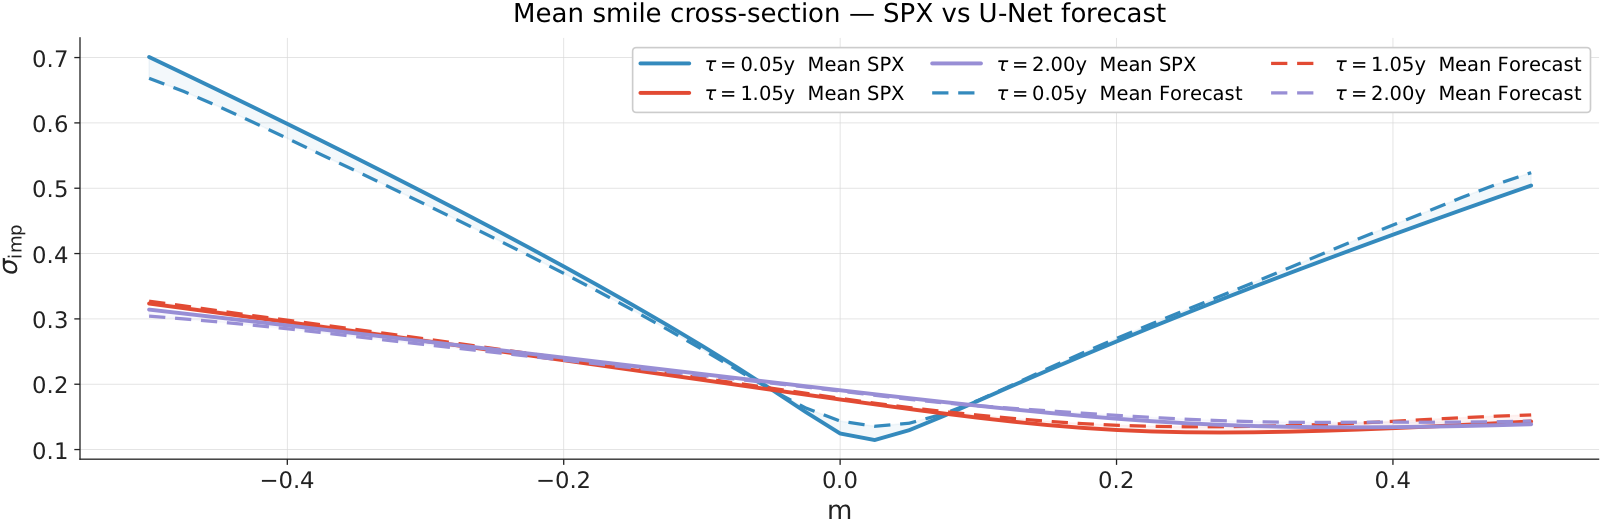

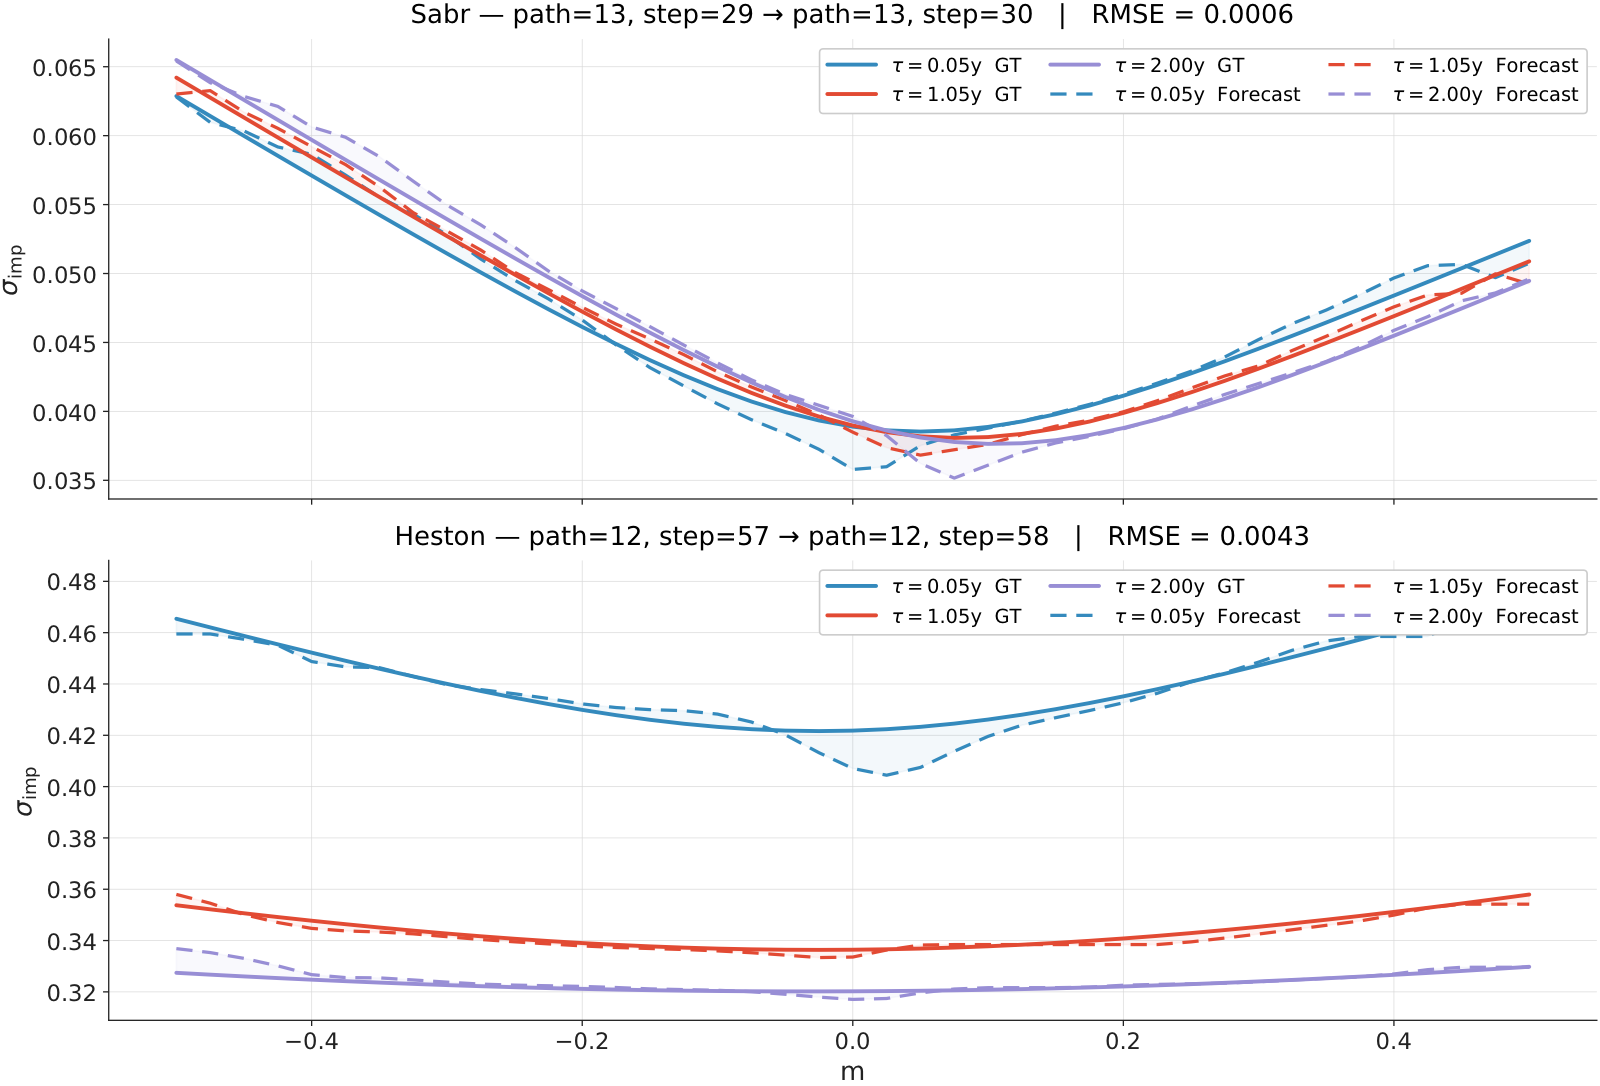

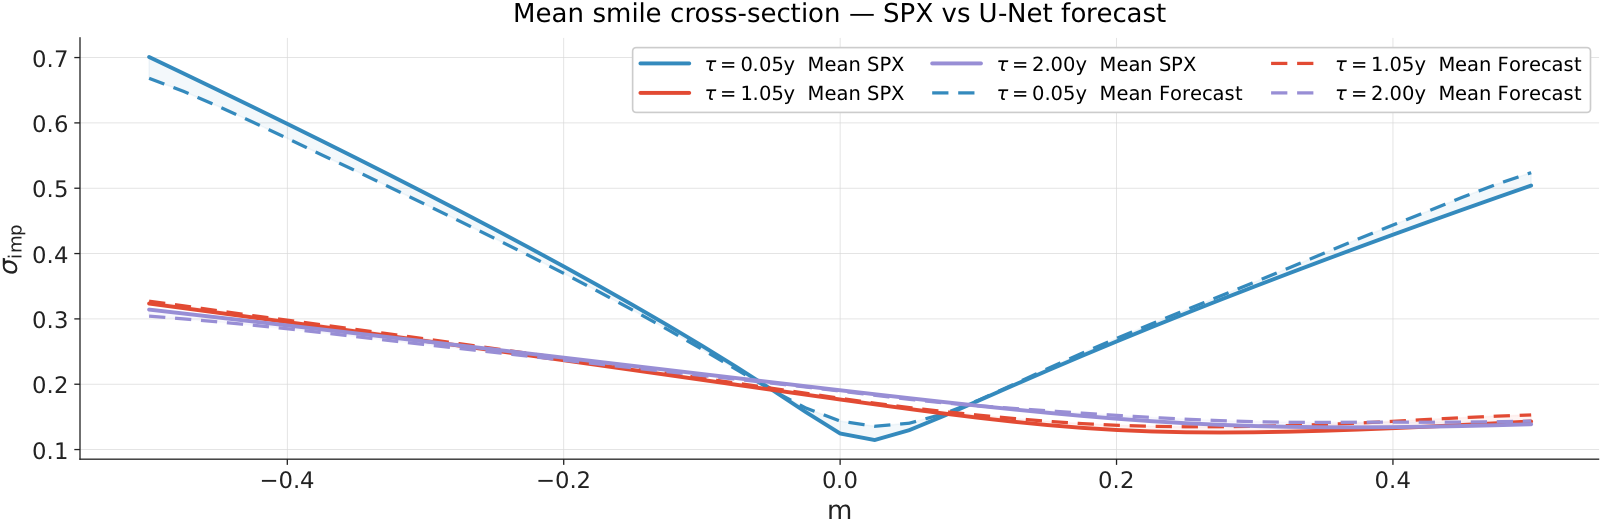

In [15]:
_hist_insts = [inst for inst in instances if inst["path_type"] == "historical"]
_synth_insts = [inst for inst in display_instances if inst["path_type"] != "historical"]

_xsection_groups = []
if _hist_insts:
    mean_gt = np.nanmean(np.stack([inst["ground_truth"] for inst in _hist_insts]), axis=0)
    mean_fc = np.nanmean(np.stack([inst["forecast"] for inst in _hist_insts]), axis=0)
    _xsection_groups.append(("historical", [{"ground_truth": mean_gt, "forecast": mean_fc,
        "path_type": "historical", "gt_label": f"mean (n={len(_hist_insts)})",
        "input_label": f"mean (n={len(_hist_insts)})"}]))
if _synth_insts:
    _xsection_groups.append(("synthetic", _synth_insts))

for _pdf_group_label, _group_instances in _xsection_groups:
    if not _group_instances:
        continue
    n_instances = len(_group_instances)

    with rc_context():
        fig, axes = plt.subplots(
            n_instances,
            1,
            figsize=(14, 4.8 * n_instances),
            squeeze=False,
            sharex="col",
        )
        fig.patch.set_facecolor(plt.rcParams["figure.facecolor"])

        for row, inst in enumerate(_group_instances):
            ax = axes[row, 0]
            gt_iv = inst["ground_truth"]
            fc_iv = inst["forecast"]
            path_label = inst["path_type"].capitalize()

            for j, tidx in enumerate(tenor_idx):
                color = TENOR_COLORS[j % len(TENOR_COLORS)]
                tenor_label = rf"$\tau = {tau_axis[tidx]:.2f}$y"
                gt_lbl = f"{tenor_label}  Mean SPX" if inst["path_type"] == "historical" else f"{tenor_label}  GT"
                fc_lbl = f"{tenor_label}  Mean Forecast" if inst["path_type"] == "historical" else f"{tenor_label}  Forecast"
                ax.plot(m_axis, gt_iv[:, tidx], color=color, lw=2.4, solid_capstyle="round", label=gt_lbl)
                ax.plot(
                    m_axis,
                    fc_iv[:, tidx],
                    color=color,
                    lw=2.0,
                    ls="--",
                    dashes=(5, 3),
                    label=fc_lbl,
                )
                ax.fill_between(m_axis, gt_iv[:, tidx], fc_iv[:, tidx], color=color, alpha=0.06)

            rmse = float(np.sqrt(np.nanmean((fc_iv - gt_iv) ** 2)))
            if inst["path_type"] == "historical":
                title_str = f"Mean smile cross-section — SPX vs U-Net forecast"
            else:
                title_str = f"{path_label} — {inst['input_label']} → {inst['gt_label']}   |   RMSE = {rmse:.4f}"
            ax.set_title(title_str, fontsize=XSEC_TITLE_FONTSIZE, pad=10)
            ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$", fontsize=XSEC_LABEL_FONTSIZE)
            style_2d_axes(ax)
            ax.tick_params(labelsize=XSEC_TICK_LABELSIZE)
            handles, labels = ax.get_legend_handles_labels()
            ncol = min(TENOR_SLICES_PER_SURFACE, 5)
            gt_handles = handles[0::2]
            fc_handles = handles[1::2]
            gt_labels = labels[0::2]
            fc_labels = labels[1::2]
            ax.legend(
                gt_handles + fc_handles,
                gt_labels + fc_labels,
                ncols=ncol,
                loc="upper right",
                handlelength=2.5,
                columnspacing=1.4,
                fontsize=XSEC_LEGEND_FONTSIZE,
            )

        axes[-1, 0].set_xlabel(r"m", fontsize=XSEC_LABEL_FONTSIZE)

        fig.tight_layout()
        fig.savefig(
            f"unet_vqvae_cross_section_{_pdf_group_label}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        if _pdf_group_label == "historical":
            fig.savefig(
                "unet_vqvae_mean_smile_cross_section.pdf",
                format="pdf",
                bbox_inches="tight",
            )
        plt.show()


## Model performance (historical only)

In [16]:
from scipy import stats as scipy_stats

_hist_df = forecast_error_df[
    (forecast_error_df["path_type"] == "historical") & (forecast_error_df["forecast_variant"] == "repaired")
]
_hist_instances = [inst for inst in instances if inst["path_type"] == "historical"]
if _hist_df.empty or not _hist_instances:
    raise RuntimeError("no historical validation instances; cannot compute historical-only metrics")

_n_inst = int(len(_hist_instances))
_rmse_inst = _hist_df["rmse"].to_numpy(dtype=float)
_mape_inst = _hist_df["mape_pct"].to_numpy(dtype=float)

_mean_rmse = float(np.mean(_rmse_inst))
_mean_mape_pct = float(np.mean(_mape_inst))

_BOOT_N = 10_000
_boot_rng = np.random.default_rng(int(VALIDATION_SEED) + 31)
_boot_idx = _boot_rng.integers(0, _n_inst, size=(_BOOT_N, _n_inst))
_rmse_boot = np.mean(_rmse_inst[_boot_idx], axis=1)
_mape_boot = np.mean(_mape_inst[_boot_idx], axis=1)
_rmse_ci95 = tuple(np.percentile(_rmse_boot, [2.5, 97.5]).astype(float))
_mape_ci95 = tuple(np.percentile(_mape_boot, [2.5, 97.5]).astype(float))

_arb_violation_rate = float(np.mean([not bool(inst["meta"]["forecast_arb_free"]) for inst in _hist_instances]))

_err_pooled = np.concatenate([(inst["forecast"] - inst["ground_truth"]).ravel() for inst in _hist_instances])
_err_pooled = _err_pooled[np.isfinite(_err_pooled)]

_error_mean = float(np.mean(_err_pooled)) if _err_pooled.size else float("nan")
_error_std = float(np.std(_err_pooled, ddof=1)) if _err_pooled.size > 1 else float("nan")
_error_skew = float(scipy_stats.skew(_err_pooled, bias=False)) if _err_pooled.size > 2 else float("nan")
_error_kurtosis_excess = (
    float(scipy_stats.kurtosis(_err_pooled, fisher=True, bias=False)) if _err_pooled.size > 3 else float("nan")
)

performance_summary = pd.DataFrame(
    [
        {
            "metrics_scope": "historical",
            "n_validation_instances": _n_inst,
            "mean_rmse": _mean_rmse,
            "rmse_mean_ci95_low": _rmse_ci95[0],
            "rmse_mean_ci95_high": _rmse_ci95[1],
            "mean_mape_pct": _mean_mape_pct,
            "mape_mean_ci95_low_pct": _mape_ci95[0],
            "mape_mean_ci95_high_pct": _mape_ci95[1],
            "forecast_arbitrage_violation_rate": _arb_violation_rate,
            "pooled_error_mean": _error_mean,
            "pooled_error_std": _error_std,
            "pooled_error_skew": _error_skew,
            "pooled_error_kurtosis_excess": _error_kurtosis_excess,
            "pooled_error_n_points": int(_err_pooled.size),
        }
    ]
)
display(performance_summary)

_LOG_K_2D = np.broadcast_to(
    np.asarray(GRID.log_moneyness, dtype=float)[:, np.newaxis],
    GRID.shape,
)
_MONEYNESS_BANDS = (
    ("ITM", "k < -0.10", _LOG_K_2D < -0.10),
    ("ATM", "|k| <= 0.10", np.abs(_LOG_K_2D) <= 0.10),
    ("OTM", "k > 0.10", _LOG_K_2D > 0.10),
)
_diff_pooled = np.concatenate([(inst["forecast"] - inst["ground_truth"]).ravel() for inst in _hist_instances])
_gt_pooled = np.concatenate([inst["ground_truth"].ravel() for inst in _hist_instances])
_gt_abs_pooled = np.abs(_gt_pooled)
_finite_pooled = np.isfinite(_diff_pooled) & np.isfinite(_gt_pooled)
_moneyness_region_rows = []
for _label, _rule, _band_2d in _MONEYNESS_BANDS:
    _band_flat = np.tile(_band_2d.ravel(), _n_inst)
    _mask = _finite_pooled & _band_flat
    _n_pts = int(np.sum(_mask))
    if _n_pts:
        _err = _diff_pooled[_mask]
        _rmse = float(np.sqrt(np.mean(_err * _err)))
        _mape_mask = _mask & (_gt_abs_pooled > float(IV_FLOOR_SAMPLE))
        _mape_pct = (
            float(100.0 * np.mean(np.abs(_diff_pooled[_mape_mask]) / _gt_abs_pooled[_mape_mask]))
            if np.any(_mape_mask)
            else float("nan")
        )
    else:
        _rmse = float("nan")
        _mape_pct = float("nan")
    _moneyness_region_rows.append(
        {
            "moneyness": _label,
            "k_rule": _rule,
            "n_points": _n_pts,
            "rmse": _rmse,
            "mape_pct": _mape_pct,
        }
    )

moneyness_region_metrics_df = pd.DataFrame(_moneyness_region_rows)
display(moneyness_region_metrics_df)

print(
    f"[historical] Mean RMSE={_mean_rmse:.6g} (95% bootstrap CI for mean RMSE: [{_rmse_ci95[0]:.6g}, {_rmse_ci95[1]:.6g}])"
)
print(
    f"[historical] Mean MAPE={_mean_mape_pct:.4f}% (95% bootstrap CI for mean MAPE: [{_mape_ci95[0]:.4f}%, {_mape_ci95[1]:.4f}%])"
)
print(f"[historical] Forecast arbitrage violation rate={100.0 * _arb_violation_rate:.2f}%")
print(
    f"[historical] Pooled forecast error: mean={_error_mean:.6g}, std={_error_std:.6g}, "
    f"skew={_error_skew:.6g}, excess kurtosis={_error_kurtosis_excess:.6g} (n={_err_pooled.size})"
)

[historical] Mean RMSE=0.0158142 (95% bootstrap CI for mean RMSE: [0.0148569, 0.0168091])
[historical] Mean MAPE=5.0050% (95% bootstrap CI for mean MAPE: [4.5792%, 5.4603%])
[historical] Forecast arbitrage violation rate=0.00%
[historical] Pooled forecast error: mean=0.00370891, std=0.0172558, skew=0.0648829, excess kurtosis=19.6798 (n=408360)


,metrics_scope,n_validation_instances,mean_rmse,rmse_mean_ci95_low,rmse_mean_ci95_high,mean_mape_pct,mape_mean_ci95_low_pct,mape_mean_ci95_high_pct,forecast_arbitrage_violation_rate,pooled_error_mean,pooled_error_std,pooled_error_skew,pooled_error_kurtosis_excess,pooled_error_n_points
0,historical,249,0.015814,0.014857,0.016809,5.00499,4.579243,5.460316,0.0,0.003709,0.017256,0.064883,19.679803,408360


,moneyness,k_rule,n_points,rmse,mape_pct
0,ITM,k < -0.10,159360,0.018595,3.524955
1,ATM,|k| <= 0.10,79680,0.009690,3.714202
2,OTM,k > 0.10,169320,0.019537,7.005395


## DDIM denoising trajectory


In [17]:
_SNAPSHOT_REQUESTED = [199, 100, 50, 5]
_DDIM_CMAP = "turbo"

if HARD_HIST_AVAILABLE:
    _demo_s_curr = HARD_S_CURR
    _demo_seed = int(VALIDATION_SEED + 7700)
    _ddim_date_note = (
        f"{HARD_HIST_DATE_CURR.date()} $\\rightarrow$ {HARD_HIST_DATE_NEXT.date()} "
        f"(largest historical IV jump, RMSE={HARD_HIST_JUMP_RMSE:.4f})"
    )
else:
    _demo_inst = next(inst for inst in display_instances if inst["path_type"] == "historical")
    _demo_s_curr = _demo_inst["input"]
    _demo_seed = int(_demo_inst["meta"]["seed"])
    _ddim_date_note = str(_demo_inst["input_label"])

_demo_cond_iv = torch.as_tensor(_demo_s_curr, dtype=torch.float32, device=DEVICE)[None, None]
_demo_cond_z = model.normalize(_demo_cond_iv)

if SAMPLER_USE_GENERATOR:
    _snap_gen = torch.Generator().manual_seed(_demo_seed)
else:
    _snap_gen = None
    torch.manual_seed(_demo_seed)

_snapshot_z: dict[int, np.ndarray] = {}


def _capture_snapshot(t_idx: int, z_t: torch.Tensor, x0_z: torch.Tensor) -> None:
    _snapshot_z[t_idx] = model.denormalize(x0_z).detach().cpu().numpy()[0, 0]


_snap_shape = (1, model.in_channels, *GRID.shape)
_z_init = torch.randn(
    _snap_shape,
    device=DEVICE,
    generator=_snap_gen if SAMPLER_USE_GENERATOR else None,
)
_initial_noise = model.denormalize(_z_init).detach().cpu().numpy()[0, 0]

T = sampler.scheduler.timesteps
_step_indices = torch.linspace(0, T - 1, DDIM_STEPS + 1, device=DEVICE).round().long()
_step_indices = torch.unique(_step_indices, sorted=True).flip(0)

_z_t = _z_init.clone()
for _i in range(_step_indices.shape[0] - 1):
    _t_idx = int(_step_indices[_i].item())
    _t_prev_idx = int(_step_indices[_i + 1].item())
    _t = torch.full((_snap_shape[0],), _t_idx, device=DEVICE, dtype=torch.long)
    _t_prev = torch.full((_snap_shape[0],), _t_prev_idx, device=DEVICE, dtype=torch.long)

    _eps, _x0_z = sampler._eps_and_x0_z(_z_t, _t, _demo_cond_z, SAMPLER_CLIP_Z)

    _ab_t = sampler.scheduler.alpha_bar_at(_t).view(-1, 1, 1, 1)
    _ab_prev = sampler.scheduler.alpha_bar_at(_t_prev).view(-1, 1, 1, 1)
    _sigma = 0.0
    _dir_xt = torch.sqrt(torch.clamp(1.0 - _ab_prev - _sigma**2, min=0.0)) * _eps
    _z_t = torch.sqrt(_ab_prev) * _x0_z + _dir_xt

    _capture_snapshot(_t_idx, _z_t, _x0_z)

_final_surface = model.denormalize(_z_t).detach().cpu().numpy()[0, 0]

_visited_ts = sorted(_snapshot_z)
_panel_data: list[tuple[str, np.ndarray]] = [
    (f"DDIM $= {T}$", _initial_noise),
]
for _t_req in _SNAPSHOT_REQUESTED:
    if not (0 <= _t_req < T):
        continue
    _t_actual = min(_visited_ts, key=lambda t: abs(t - _t_req))
    _panel_data.append((f"DDIM $= {_t_actual}$", _snapshot_z[_t_actual]))
_panel_data.append(("DDIM $= 0$", _final_surface))


def _ddim_panel_vlims(arr: np.ndarray) -> tuple[float, float]:
    x = np.asarray(arr, dtype=np.float64)
    vmin = float(np.nanmin(x))
    vmax = float(np.nanmax(x))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return 0.0, 1.0
    if vmin >= vmax:
        vmax = vmin + 1e-6
    return vmin, vmax


m_ax = np.asarray(GRID.log_moneyness, dtype=np.float64)
tau_ax = np.asarray(GRID.tau, dtype=np.float64)
_m_span = float(m_ax[-1] - m_ax[0])
_tau_span = float(tau_ax[-1] - tau_ax[0])
_heatmap_aspect = _tau_span / _m_span
MM, TT = np.meshgrid(m_ax, tau_ax, indexing="ij")

_n_cols = 3
_n_rows = 2


<ipython-input-18-14dcd890f7f3>:38:   plt.show()
<ipython-input-18-14dcd890f7f3>:76:   plt.show()


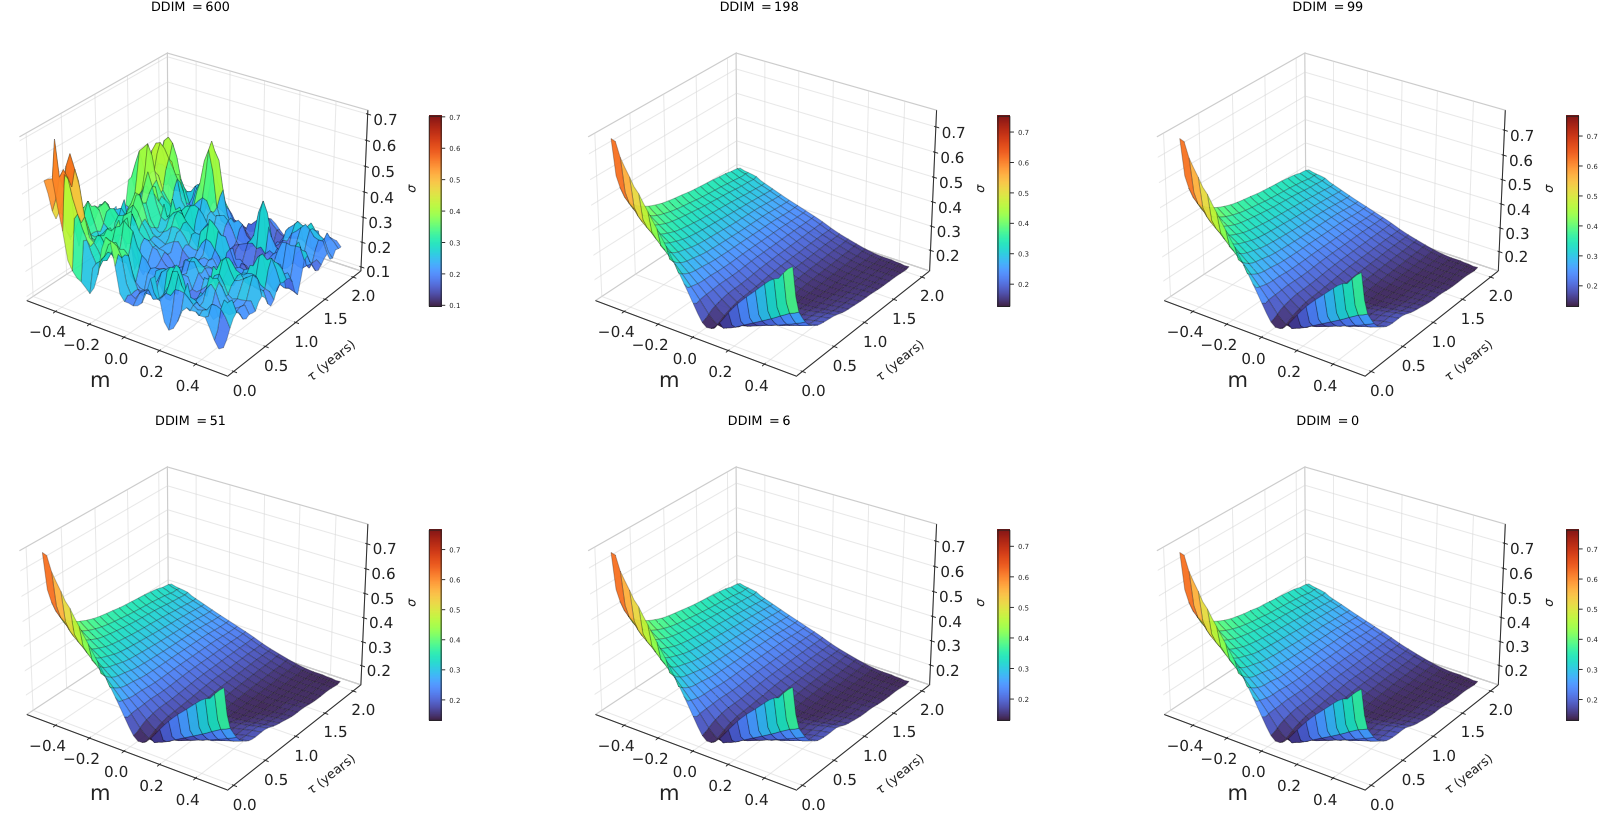

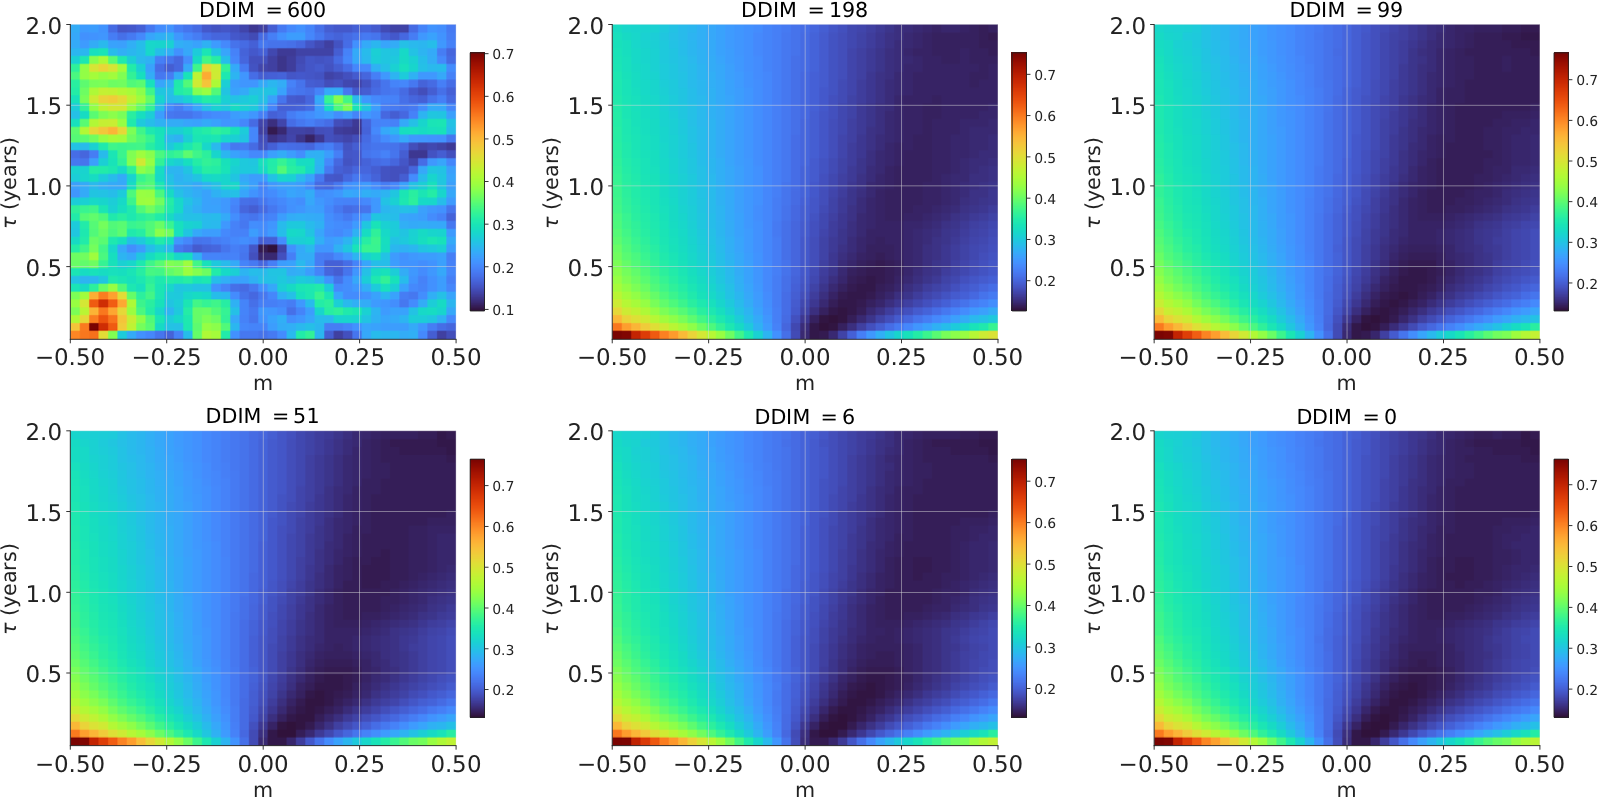

In [18]:
with rc_context():
    fig3d = plt.figure(figsize=(21, 10))
    fig3d.patch.set_facecolor("white")

    for idx, (title, data) in enumerate(_panel_data):
        ax3d = fig3d.add_subplot(_n_rows, _n_cols, idx + 1, projection="3d")
        vmin, vmax = _ddim_panel_vlims(data)
        surf = ax3d.plot_surface(
            MM,
            TT,
            data,
            cmap=_DDIM_CMAP,
            vmin=vmin,
            vmax=vmax,
            linewidth=0.15,
            edgecolor="k",
            alpha=0.92,
            antialiased=True,
            rstride=2,
            cstride=2,
        )
        ax3d.set_title(title, fontsize=11, pad=8)
        ax3d.set_xlabel(r"m", labelpad=6, fontsize=18)
        ax3d.set_ylabel(r"$\tau$ (years)", labelpad=8, fontsize=11)
        ax3d.set_zlabel(r"$\sigma$", labelpad=4, fontsize=11)
        ax3d.view_init(elev=28, azim=-55)
        ax3d.tick_params(labelsize=7, pad=1)
        style_3d_axes(ax3d)
        cb = fig3d.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.08, aspect=16)
        cb.ax.tick_params(labelsize=6)

    fig3d.tight_layout()
    fig3d.savefig(
        "unet_vqvae_ddim_trajectory_3d.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

    m_ticks = np.arange(
        np.ceil(m_ax[0] / 0.25) * 0.25,
        m_ax[-1] + 1e-9,
        0.25,
    )

    fig2d = plt.figure(figsize=(20, 10))
    fig2d.patch.set_facecolor("white")

    for idx, (title, data) in enumerate(_panel_data):
        ax2d = fig2d.add_subplot(_n_rows, _n_cols, idx + 1)
        vmin, vmax = _ddim_panel_vlims(data)
        im = ax2d.imshow(
            data.T,
            origin="lower",
            aspect="auto",
            cmap=_DDIM_CMAP,
            vmin=vmin,
            vmax=vmax,
            extent=[m_ax[0], m_ax[-1], tau_ax[0], tau_ax[-1]],
        )
        ax2d.set_title(title, fontsize=18)
        ax2d.set_xlabel(r"m", fontsize=18)
        ax2d.set_ylabel(r"$\tau$ (years)", fontsize=18)
        ax2d.set_xticks(m_ticks)
        ax2d.tick_params(labelsize=20)
        style_2d_axes(ax2d)
        cb2 = fig2d.colorbar(im, ax=ax2d, shrink=0.82, pad=0.03, aspect=18)
        cb2.ax.tick_params(labelsize=12)

    fig2d.tight_layout()
    fig2d.savefig(
        "unet_vqvae_ddim_trajectory_heatmap.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()
